# Missing Label Context Extraction

This notebook extracts the raw context around missing rows in `train_labels.csv`.

Outputs:

- Missing label timestamps by KPX group
- 10-minute SCADA rows for every turbine in the corresponding group
- LDAPS/GFS forecast rows averaged over `grid_id` at each missing forecast timestamp
- LDAPS/GFS raw missing-value audit tables
- SCADA raw missing-value audit tables
- SCADA wind-direction hourly/monthly/seasonal summaries linked to LDAPS grid IDs
- SCADA month-hour and season-hour wind-direction heatmaps and polar plots

SCADA hour alignment follows the competition label convention:

- A label at `11:00` corresponds to the six 10-minute SCADA records `10:10, 10:20, ..., 11:00`.
- Therefore, this notebook filters SCADA rows where `missing_time - 1 hour < kst_dtm <= missing_time`.

Group mapping:

- `kpx_group_1`: VESTAS turbine 1-6
- `kpx_group_2`: VESTAS turbine 7-12
- `kpx_group_3`: UNISON turbine 1-5

For `kpx_group_3`, 2022 labels are intentionally not treated as missing because group 3 generation starts from 2023.


In [1]:

from pathlib import Path
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

plt.rcParams["font.family"] = ["Malgun Gothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", context="notebook")


## 1. Configuration


In [2]:

# If you run this notebook in the local BARAM 2026 folder, Path.cwd() should be the project root.
# Adjust BASE_DIR manually if needed.
BASE_DIR = Path.cwd()
TRAIN_DIR = BASE_DIR / "train"
OUTPUT_DIR = BASE_DIR / "outputs" / "missing_label_context"
PLOT_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_PATH = TRAIN_DIR / "train_labels.csv"
SCADA_VESTAS_PATH = TRAIN_DIR / "scada_vestas_train.csv"
SCADA_UNISON_PATH = TRAIN_DIR / "scada_unison_train.csv"
LDAPS_PATH = TRAIN_DIR / "ldaps_train.csv"
GFS_PATH = TRAIN_DIR / "gfs_train.csv"
TURBINE_GRID_PATH = BASE_DIR / "outputs" / "turbine_nearest_weather_grids.csv"

TARGET_COLS = ["kpx_group_1", "kpx_group_2", "kpx_group_3"]

VESTAS_GROUP_MAP = {**{i: "kpx_group_1" for i in range(1, 7)}, **{i: "kpx_group_2" for i in range(7, 13)}}
UNISON_GROUP_MAP = {i: "kpx_group_3" for i in range(1, 6)}

GROUP3_VALID_START = pd.Timestamp("2023-01-01 00:00:00")
EXPECTED_SCADA_RECORDS_PER_MISSING_HOUR = 6

OUTPUT_PATHS = {
    "missing_timestamps": OUTPUT_DIR / "missing_label_timestamps.csv",
    "scada_10min": OUTPUT_DIR / "missing_label_scada_10min_rows.csv",
    "ldaps_mean": OUTPUT_DIR / "missing_label_ldaps_grid_mean.csv",
    "gfs_mean": OUTPUT_DIR / "missing_label_gfs_grid_mean.csv",
    "weather_mean": OUTPUT_DIR / "missing_label_weather_grid_mean.csv",
    "ldaps_weather_context_stats": OUTPUT_DIR / "missing_label_ldaps_weather_context_grid_stats_long.csv",
    "ldaps_wind_stats": OUTPUT_DIR / "missing_label_ldaps_wind_grid_stats_long.csv",
    "gfs_wind_stats": OUTPUT_DIR / "missing_label_gfs_wind_grid_stats_long.csv",
    "scada_hourly_wind_stats": OUTPUT_DIR / "missing_label_scada_hourly_wind_stats_long.csv",
    "weather_missing_summary": OUTPUT_DIR / "weather_missing_summary.csv",
    "ldaps_missing_by_column": OUTPUT_DIR / "ldaps_missing_by_column.csv",
    "gfs_missing_by_column": OUTPUT_DIR / "gfs_missing_by_column.csv",
    "ldaps_missing_by_forecast_time": OUTPUT_DIR / "ldaps_missing_by_forecast_time.csv",
    "gfs_missing_by_forecast_time": OUTPUT_DIR / "gfs_missing_by_forecast_time.csv",
    "ldaps_missing_by_grid": OUTPUT_DIR / "ldaps_missing_by_grid.csv",
    "gfs_missing_by_grid": OUTPUT_DIR / "gfs_missing_by_grid.csv",
    "ldaps_missing_rows": OUTPUT_DIR / "ldaps_rows_with_missing_values.csv",
    "gfs_missing_rows": OUTPUT_DIR / "gfs_rows_with_missing_values.csv",
    "scada_missing_summary": OUTPUT_DIR / "scada_missing_summary.csv",
    "scada_vestas_missing_by_column": OUTPUT_DIR / "scada_vestas_missing_by_column.csv",
    "scada_unison_missing_by_column": OUTPUT_DIR / "scada_unison_missing_by_column.csv",
    "scada_missing_by_timestamp": OUTPUT_DIR / "scada_missing_by_timestamp.csv",
    "scada_missing_by_turbine_variable": OUTPUT_DIR / "scada_missing_by_turbine_variable.csv",
    "scada_vestas_missing_rows": OUTPUT_DIR / "scada_vestas_rows_with_missing_values.csv",
    "scada_unison_missing_rows": OUTPUT_DIR / "scada_unison_rows_with_missing_values.csv",
    "scada_wd_turbine_ldaps_map": OUTPUT_DIR / "scada_wind_direction_turbine_ldaps_map.csv",
    "scada_wd_hourly_summary": OUTPUT_DIR / "scada_wind_direction_hourly_summary_with_ldaps.csv",
    "scada_wd_hour_sector_distribution": OUTPUT_DIR / "scada_wind_direction_hour_sector_distribution_with_ldaps.csv",
    "scada_wd_monthly_summary": OUTPUT_DIR / "scada_wind_direction_monthly_summary_with_ldaps.csv",
    "scada_wd_month_sector_distribution": OUTPUT_DIR / "scada_wind_direction_month_sector_distribution_with_ldaps.csv",
    "scada_wd_seasonal_summary": OUTPUT_DIR / "scada_wind_direction_seasonal_summary_with_ldaps.csv",
    "scada_wd_season_sector_distribution": OUTPUT_DIR / "scada_wind_direction_season_sector_distribution_with_ldaps.csv",
    "scada_wd_ldaps_grid_hourly_summary": OUTPUT_DIR / "scada_wind_direction_ldaps_grid_hourly_summary.csv",
    "scada_wd_ldaps_grid_monthly_summary": OUTPUT_DIR / "scada_wind_direction_ldaps_grid_monthly_summary.csv",
    "scada_wd_ldaps_grid_seasonal_summary": OUTPUT_DIR / "scada_wind_direction_ldaps_grid_seasonal_summary.csv",
    "scada_wd_month_hourly_summary": OUTPUT_DIR / "scada_wind_direction_month_hourly_summary_with_ldaps.csv",
    "scada_wd_month_hour_sector_distribution": OUTPUT_DIR / "scada_wind_direction_month_hour_sector_distribution_with_ldaps.csv",
    "scada_wd_season_hourly_summary": OUTPUT_DIR / "scada_wind_direction_season_hourly_summary_with_ldaps.csv",
    "scada_wd_season_hour_sector_distribution": OUTPUT_DIR / "scada_wind_direction_season_hour_sector_distribution_with_ldaps.csv",
    "scada_wd_ldaps_grid_month_hourly_summary": OUTPUT_DIR / "scada_wind_direction_ldaps_grid_month_hourly_summary.csv",
    "scada_wd_ldaps_grid_season_hourly_summary": OUTPUT_DIR / "scada_wind_direction_ldaps_grid_season_hourly_summary.csv",
}

print("BASE_DIR:", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("PLOT_DIR:", PLOT_DIR)


BASE_DIR: C:\Users\심현석\Documents\BARAM 2026
OUTPUT_DIR: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context
PLOT_DIR: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots


## 2. Load Data


In [3]:
required_paths = [LABEL_PATH, SCADA_VESTAS_PATH, SCADA_UNISON_PATH, LDAPS_PATH, GFS_PATH]
missing_paths = [str(p) for p in required_paths if not p.exists()]
if missing_paths:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing_paths))

labels = pd.read_csv(LABEL_PATH)
scada_vestas = pd.read_csv(SCADA_VESTAS_PATH)
scada_unison = pd.read_csv(SCADA_UNISON_PATH)
ldaps = pd.read_csv(LDAPS_PATH)
gfs = pd.read_csv(GFS_PATH)

labels["kst_dtm"] = pd.to_datetime(labels["kst_dtm"])
scada_vestas["kst_dtm"] = pd.to_datetime(scada_vestas["kst_dtm"])
scada_unison["kst_dtm"] = pd.to_datetime(scada_unison["kst_dtm"])

for df in [ldaps, gfs]:
    df["forecast_kst_dtm"] = pd.to_datetime(df["forecast_kst_dtm"])
    df["data_available_kst_dtm"] = pd.to_datetime(df["data_available_kst_dtm"])

labels = labels.sort_values("kst_dtm").reset_index(drop=True)
scada_vestas = scada_vestas.sort_values("kst_dtm").reset_index(drop=True)
scada_unison = scada_unison.sort_values("kst_dtm").reset_index(drop=True)

print("labels:", labels.shape, labels["kst_dtm"].min(), "~", labels["kst_dtm"].max())
print("scada_vestas:", scada_vestas.shape, scada_vestas["kst_dtm"].min(), "~", scada_vestas["kst_dtm"].max())
print("scada_unison:", scada_unison.shape, scada_unison["kst_dtm"].min(), "~", scada_unison["kst_dtm"].max())
print("ldaps:", ldaps.shape, ldaps["forecast_kst_dtm"].min(), "~", ldaps["forecast_kst_dtm"].max())
print("gfs:", gfs.shape, gfs["forecast_kst_dtm"].min(), "~", gfs["forecast_kst_dtm"].max())

labels: (26304, 4) 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
scada_vestas: (157819, 37) 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
scada_unison: (105264, 16) 2023-01-01 00:10:00 ~ 2025-01-01 00:00:00
ldaps: (420864, 35) 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
gfs: (236736, 40) 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00


## 3. Raw Missing-Value Audits

### 3.1 LDAPS/GFS Missing Values


In [4]:

def audit_weather_missing_values(weather_df: pd.DataFrame, source_name: str) -> dict[str, pd.DataFrame]:
    key_cols = [c for c in ["forecast_kst_dtm", "data_available_kst_dtm", "grid_id", "latitude", "longitude"] if c in weather_df.columns]
    n_rows, n_cols = weather_df.shape
    row_missing_counts = weather_df.isna().sum(axis=1)
    rows_with_missing_mask = row_missing_counts > 0

    by_column = pd.DataFrame(
        {
            "source": source_name,
            "column": weather_df.columns,
            "dtype": [str(weather_df[c].dtype) for c in weather_df.columns],
            "n_missing": [int(weather_df[c].isna().sum()) for c in weather_df.columns],
            "missing_rate": [float(weather_df[c].isna().mean()) for c in weather_df.columns],
            "n_unique_non_null": [int(weather_df[c].nunique(dropna=True)) for c in weather_df.columns],
        }
    ).sort_values(["n_missing", "column"], ascending=[False, True]).reset_index(drop=True)

    missing_rows = weather_df.loc[rows_with_missing_mask, key_cols].copy()
    if not missing_rows.empty:
        missing_rows.insert(0, "source", source_name)
        missing_rows["n_missing_in_row"] = row_missing_counts.loc[rows_with_missing_mask].to_numpy()
        missing_cols_per_row = weather_df.loc[rows_with_missing_mask].isna().apply(
            lambda row: ", ".join(row.index[row.to_numpy()]), axis=1
        )
        missing_rows["missing_columns"] = missing_cols_per_row.to_numpy()
    else:
        missing_rows = pd.DataFrame(columns=["source", *key_cols, "n_missing_in_row", "missing_columns"])

    working = weather_df[key_cols].copy()
    working["n_missing_in_row"] = row_missing_counts
    working["has_missing"] = rows_with_missing_mask

    by_forecast_time = (
        working
        .groupby("forecast_kst_dtm", as_index=False)
        .agg(
            n_rows=("has_missing", "size"),
            n_rows_with_missing=("has_missing", "sum"),
            n_missing_cells=("n_missing_in_row", "sum"),
        )
        .sort_values(["n_missing_cells", "forecast_kst_dtm"], ascending=[False, True])
        .reset_index(drop=True)
    )
    by_forecast_time.insert(0, "source", source_name)
    by_forecast_time["missing_row_rate"] = by_forecast_time["n_rows_with_missing"] / by_forecast_time["n_rows"]
    by_forecast_time["missing_cell_rate"] = by_forecast_time["n_missing_cells"] / (by_forecast_time["n_rows"] * n_cols)

    if "grid_id" in working.columns:
        by_grid = (
            working
            .groupby("grid_id", as_index=False)
            .agg(
                n_rows=("has_missing", "size"),
                n_rows_with_missing=("has_missing", "sum"),
                n_missing_cells=("n_missing_in_row", "sum"),
            )
            .sort_values(["n_missing_cells", "grid_id"], ascending=[False, True])
            .reset_index(drop=True)
        )
        by_grid.insert(0, "source", source_name)
        by_grid["missing_row_rate"] = by_grid["n_rows_with_missing"] / by_grid["n_rows"]
        by_grid["missing_cell_rate"] = by_grid["n_missing_cells"] / (by_grid["n_rows"] * n_cols)
    else:
        by_grid = pd.DataFrame(columns=["source", "grid_id", "n_rows", "n_rows_with_missing", "n_missing_cells", "missing_row_rate", "missing_cell_rate"])

    forecast_times_with_missing = by_forecast_time[by_forecast_time["n_missing_cells"] > 0]
    summary = pd.DataFrame(
        [
            {
                "source": source_name,
                "n_rows": n_rows,
                "n_columns": n_cols,
                "n_cells": n_rows * n_cols,
                "n_missing_cells": int(row_missing_counts.sum()),
                "missing_cell_rate": float(row_missing_counts.sum() / (n_rows * n_cols)),
                "n_rows_with_missing": int(rows_with_missing_mask.sum()),
                "missing_row_rate": float(rows_with_missing_mask.mean()),
                "n_columns_with_missing": int((by_column["n_missing"] > 0).sum()),
                "n_forecast_times_with_missing": int(len(forecast_times_with_missing)),
                "first_missing_forecast_kst_dtm": forecast_times_with_missing["forecast_kst_dtm"].min() if not forecast_times_with_missing.empty else pd.NaT,
                "last_missing_forecast_kst_dtm": forecast_times_with_missing["forecast_kst_dtm"].max() if not forecast_times_with_missing.empty else pd.NaT,
            }
        ]
    )

    return {
        "summary": summary,
        "by_column": by_column,
        "by_forecast_time": by_forecast_time,
        "by_grid": by_grid,
        "missing_rows": missing_rows,
    }


ldaps_missing_audit = audit_weather_missing_values(ldaps, "ldaps")
gfs_missing_audit = audit_weather_missing_values(gfs, "gfs")
weather_missing_summary = pd.concat(
    [ldaps_missing_audit["summary"], gfs_missing_audit["summary"]],
    ignore_index=True,
)

weather_missing_summary.to_csv(OUTPUT_PATHS["weather_missing_summary"], index=False, encoding="utf-8-sig")
ldaps_missing_audit["by_column"].to_csv(OUTPUT_PATHS["ldaps_missing_by_column"], index=False, encoding="utf-8-sig")
gfs_missing_audit["by_column"].to_csv(OUTPUT_PATHS["gfs_missing_by_column"], index=False, encoding="utf-8-sig")
ldaps_missing_audit["by_forecast_time"].to_csv(OUTPUT_PATHS["ldaps_missing_by_forecast_time"], index=False, encoding="utf-8-sig")
gfs_missing_audit["by_forecast_time"].to_csv(OUTPUT_PATHS["gfs_missing_by_forecast_time"], index=False, encoding="utf-8-sig")
ldaps_missing_audit["by_grid"].to_csv(OUTPUT_PATHS["ldaps_missing_by_grid"], index=False, encoding="utf-8-sig")
gfs_missing_audit["by_grid"].to_csv(OUTPUT_PATHS["gfs_missing_by_grid"], index=False, encoding="utf-8-sig")
ldaps_missing_audit["missing_rows"].to_csv(OUTPUT_PATHS["ldaps_missing_rows"], index=False, encoding="utf-8-sig")
gfs_missing_audit["missing_rows"].to_csv(OUTPUT_PATHS["gfs_missing_rows"], index=False, encoding="utf-8-sig")

print("LDAPS/GFS missing-value summary:")
display(weather_missing_summary)

for source_name, audit in [("ldaps", ldaps_missing_audit), ("gfs", gfs_missing_audit)]:
    missing_cols = audit["by_column"].query("n_missing > 0")
    missing_times = audit["by_forecast_time"].query("n_missing_cells > 0")
    missing_grids = audit["by_grid"].query("n_missing_cells > 0")
    print(f"\n[{source_name.upper()}] columns with missing values: {len(missing_cols)}")
    display(missing_cols.head(30))
    print(f"[{source_name.upper()}] forecast timestamps with missing values: {len(missing_times)}")
    display(missing_times.head(20))
    print(f"[{source_name.upper()}] grids with missing values: {len(missing_grids)}")
    display(missing_grids.head(20))
    print(f"[{source_name.upper()}] rows with missing values: {len(audit['missing_rows'])}")
    display(audit["missing_rows"].head(20))

print("Saved missing-value audit files:")
for key in [
    "weather_missing_summary",
    "ldaps_missing_by_column",
    "gfs_missing_by_column",
    "ldaps_missing_by_forecast_time",
    "gfs_missing_by_forecast_time",
    "ldaps_missing_by_grid",
    "gfs_missing_by_grid",
    "ldaps_missing_rows",
    "gfs_missing_rows",
]:
    print(f"- {key}: {OUTPUT_PATHS[key]}")


LDAPS/GFS missing-value summary:


,source,n_rows,n_columns,n_cells,n_missing_cells,missing_cell_rate,n_rows_with_missing,missing_row_rate,n_columns_with_missing,n_forecast_times_with_missing,first_missing_forecast_kst_dtm,last_missing_forecast_kst_dtm
0,ldaps,420864,35,14730240,0,0.0,0,0.0,0,0,NaT,NaT
1,gfs,236736,40,9469440,0,0.0,0,0.0,0,0,NaT,NaT



[LDAPS] columns with missing values: 0


,source,column,dtype,n_missing,missing_rate,n_unique_non_null


[LDAPS] forecast timestamps with missing values: 0


...

[GFS] grids with missing values: 0


,source,grid_id,n_rows,n_rows_with_missing,n_missing_cells,missing_row_rate,missing_cell_rate


[GFS] rows with missing values: 0


,source,forecast_kst_dtm,data_available_kst_dtm,grid_id,latitude,longitude,n_missing_in_row,missing_columns


Saved missing-value audit files:
- weather_missing_summary: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\weather_missing_summary.csv
- ldaps_missing_by_column: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\ldaps_missing_by_column.csv
- gfs_missing_by_column: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\gfs_missing_by_column.csv
- ldaps_missing_by_forecast_time: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\ldaps_missing_by_forecast_time.csv
- gfs_missing_by_forecast_time: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\gfs_missing_by_forecast_time.csv
- ldaps_missing_by_grid: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\ldaps_missing_by_grid.csv
- gfs_missing_by_grid: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\gfs_missing_by_grid.csv
- ldaps_missing_rows: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\ldaps_rows_with_missing_values.csv
- gfs

### 3.2 SCADA Missing Values


In [5]:

def audit_scada_missing_values(scada_df: pd.DataFrame, source_name: str) -> dict[str, pd.DataFrame]:
    key_cols = [c for c in ["kst_dtm"] if c in scada_df.columns]
    n_rows, n_cols = scada_df.shape
    row_missing_counts = scada_df.isna().sum(axis=1)
    rows_with_missing_mask = row_missing_counts > 0

    by_column = pd.DataFrame(
        {
            "source": source_name,
            "column": scada_df.columns,
            "dtype": [str(scada_df[c].dtype) for c in scada_df.columns],
            "n_missing": [int(scada_df[c].isna().sum()) for c in scada_df.columns],
            "missing_rate": [float(scada_df[c].isna().mean()) for c in scada_df.columns],
            "n_unique_non_null": [int(scada_df[c].nunique(dropna=True)) for c in scada_df.columns],
        }
    ).sort_values(["n_missing", "column"], ascending=[False, True]).reset_index(drop=True)

    turbine_records = []
    pattern = re.compile(rf"^{re.escape(source_name)}_wtg(\d+)_(.+)$")
    for col in scada_df.columns:
        match = pattern.match(col)
        if match is None:
            continue
        turbine_no = int(match.group(1))
        metric = match.group(2)
        turbine_records.append(
            {
                "source": source_name,
                "turbine_no": turbine_no,
                "turbine_id": f"{source_name}_wtg{turbine_no:02d}",
                "metric": metric,
                "column": col,
                "n_missing": int(scada_df[col].isna().sum()),
                "missing_rate": float(scada_df[col].isna().mean()),
                "n_unique_non_null": int(scada_df[col].nunique(dropna=True)),
            }
        )
    by_turbine_variable = pd.DataFrame(turbine_records)
    if not by_turbine_variable.empty:
        by_turbine_variable = by_turbine_variable.sort_values(
            ["n_missing", "source", "turbine_no", "metric"],
            ascending=[False, True, True, True],
        ).reset_index(drop=True)

    missing_rows = scada_df.loc[rows_with_missing_mask, key_cols].copy()
    if not missing_rows.empty:
        missing_rows.insert(0, "source", source_name)
        missing_rows["n_missing_in_row"] = row_missing_counts.loc[rows_with_missing_mask].to_numpy()
        missing_cols_per_row = scada_df.loc[rows_with_missing_mask].isna().apply(
            lambda row: ", ".join(row.index[row.to_numpy()]), axis=1
        )
        missing_rows["missing_columns"] = missing_cols_per_row.to_numpy()
    else:
        missing_rows = pd.DataFrame(columns=["source", *key_cols, "n_missing_in_row", "missing_columns"])

    working = scada_df[key_cols].copy()
    working["n_missing_in_row"] = row_missing_counts
    working["has_missing"] = rows_with_missing_mask
    by_timestamp = (
        working
        .groupby("kst_dtm", as_index=False)
        .agg(
            n_rows=("has_missing", "size"),
            n_rows_with_missing=("has_missing", "sum"),
            n_missing_cells=("n_missing_in_row", "sum"),
        )
        .sort_values(["n_missing_cells", "kst_dtm"], ascending=[False, True])
        .reset_index(drop=True)
    )
    by_timestamp.insert(0, "source", source_name)
    by_timestamp["missing_row_rate"] = by_timestamp["n_rows_with_missing"] / by_timestamp["n_rows"]
    by_timestamp["missing_cell_rate"] = by_timestamp["n_missing_cells"] / (by_timestamp["n_rows"] * n_cols)

    timestamps_with_missing = by_timestamp[by_timestamp["n_missing_cells"] > 0]
    summary = pd.DataFrame(
        [
            {
                "source": source_name,
                "n_rows": n_rows,
                "n_columns": n_cols,
                "n_cells": n_rows * n_cols,
                "n_missing_cells": int(row_missing_counts.sum()),
                "missing_cell_rate": float(row_missing_counts.sum() / (n_rows * n_cols)),
                "n_rows_with_missing": int(rows_with_missing_mask.sum()),
                "missing_row_rate": float(rows_with_missing_mask.mean()),
                "n_columns_with_missing": int((by_column["n_missing"] > 0).sum()),
                "n_turbine_variables_with_missing": int((by_turbine_variable["n_missing"] > 0).sum()) if not by_turbine_variable.empty else 0,
                "n_timestamps_with_missing": int(len(timestamps_with_missing)),
                "first_missing_kst_dtm": timestamps_with_missing["kst_dtm"].min() if not timestamps_with_missing.empty else pd.NaT,
                "last_missing_kst_dtm": timestamps_with_missing["kst_dtm"].max() if not timestamps_with_missing.empty else pd.NaT,
            }
        ]
    )

    return {
        "summary": summary,
        "by_column": by_column,
        "by_turbine_variable": by_turbine_variable,
        "by_timestamp": by_timestamp,
        "missing_rows": missing_rows,
    }


scada_vestas_missing_audit = audit_scada_missing_values(scada_vestas, "vestas")
scada_unison_missing_audit = audit_scada_missing_values(scada_unison, "unison")
scada_missing_summary = pd.concat(
    [scada_vestas_missing_audit["summary"], scada_unison_missing_audit["summary"]],
    ignore_index=True,
)
scada_missing_by_timestamp = pd.concat(
    [scada_vestas_missing_audit["by_timestamp"], scada_unison_missing_audit["by_timestamp"]],
    ignore_index=True,
)
scada_missing_by_turbine_variable = pd.concat(
    [scada_vestas_missing_audit["by_turbine_variable"], scada_unison_missing_audit["by_turbine_variable"]],
    ignore_index=True,
)

scada_missing_summary.to_csv(OUTPUT_PATHS["scada_missing_summary"], index=False, encoding="utf-8-sig")
scada_vestas_missing_audit["by_column"].to_csv(OUTPUT_PATHS["scada_vestas_missing_by_column"], index=False, encoding="utf-8-sig")
scada_unison_missing_audit["by_column"].to_csv(OUTPUT_PATHS["scada_unison_missing_by_column"], index=False, encoding="utf-8-sig")
scada_missing_by_timestamp.to_csv(OUTPUT_PATHS["scada_missing_by_timestamp"], index=False, encoding="utf-8-sig")
scada_missing_by_turbine_variable.to_csv(OUTPUT_PATHS["scada_missing_by_turbine_variable"], index=False, encoding="utf-8-sig")
scada_vestas_missing_audit["missing_rows"].to_csv(OUTPUT_PATHS["scada_vestas_missing_rows"], index=False, encoding="utf-8-sig")
scada_unison_missing_audit["missing_rows"].to_csv(OUTPUT_PATHS["scada_unison_missing_rows"], index=False, encoding="utf-8-sig")

print("SCADA missing-value summary:")
display(scada_missing_summary)

for source_name, audit in [("vestas", scada_vestas_missing_audit), ("unison", scada_unison_missing_audit)]:
    missing_cols = audit["by_column"].query("n_missing > 0")
    missing_turbine_vars = audit["by_turbine_variable"].query("n_missing > 0")
    missing_times = audit["by_timestamp"].query("n_missing_cells > 0")
    print(f"\n[{source_name.upper()}] columns with missing values: {len(missing_cols)}")
    display(missing_cols.head(30))
    print(f"[{source_name.upper()}] turbine variables with missing values: {len(missing_turbine_vars)}")
    display(missing_turbine_vars.head(30))
    print(f"[{source_name.upper()}] timestamps with missing values: {len(missing_times)}")
    display(missing_times.head(20))
    print(f"[{source_name.upper()}] rows with missing values: {len(audit['missing_rows'])}")
    display(audit["missing_rows"].head(20))

print("Saved SCADA missing-value audit files:")
for key in [
    "scada_missing_summary",
    "scada_vestas_missing_by_column",
    "scada_unison_missing_by_column",
    "scada_missing_by_timestamp",
    "scada_missing_by_turbine_variable",
    "scada_vestas_missing_rows",
    "scada_unison_missing_rows",
]:
    print(f"- {key}: {OUTPUT_PATHS[key]}")


SCADA missing-value summary:


,source,n_rows,n_columns,n_cells,n_missing_cells,missing_cell_rate,n_rows_with_missing,missing_row_rate,n_columns_with_missing,n_turbine_variables_with_missing,n_timestamps_with_missing,first_missing_kst_dtm,last_missing_kst_dtm
0,vestas,157819,37,5839303,0,0.000000,0,0.000000,0,0,0,NaT,NaT
1,unison,105264,16,1684224,9511,0.005647,4734,0.044973,15,15,4734,2023-01-06 09:10:00,2025-01-01



[VESTAS] columns with missing values: 0


,source,column,dtype,n_missing,missing_rate,n_unique_non_null


[VESTAS] turbine variables with missing values: 0


...

[UNISON] timestamps with missing values: 4734


,source,kst_dtm,n_rows,n_rows_with_missing,n_missing_cells,missing_row_rate,missing_cell_rate
0,unison,2023-05-23 16:30:00,1,1,15,1.0,0.9375
1,unison,2023-05-23 16:40:00,1,1,15,1.0,0.9375
2,unison,2023-05-23 16:50:00,1,1,15,1.0,0.9375
3,unison,2023-05-23 17:00:00,1,1,15,1.0,0.9375
4,unison,2023-05-23 17:10:00,1,1,15,1.0,0.9375
5,unison,2023-05-23 17:20:00,1,1,15,1.0,0.9375
6,unison,2023-05-23 17:30:00,1,1,15,1.0,0.9375
7,unison,2023-05-23 17:40:00,1,1,15,1.0,0.9375
8,unison,2023-05-23 17:50:00,1,1,15,1.0,0.9375
9,unison,2023-05-23 18:00:00,1,1,15,1.0,0.9375


[UNISON] rows with missing values: 4734


,source,kst_dtm,n_missing_in_row,missing_columns
774,unison,2023-01-06 09:10:00,1,unison_wtg04_ws
775,unison,2023-01-06 09:20:00,1,unison_wtg04_ws
776,unison,2023-01-06 09:30:00,1,unison_wtg04_ws
1494,unison,2023-01-11 09:10:00,1,unison_wtg05_ws
1640,unison,2023-01-12 09:30:00,1,unison_wtg05_ws
1782,unison,2023-01-13 09:10:00,1,unison_wtg05_ws
1784,unison,2023-01-13 09:30:00,1,unison_wtg03_ws
1787,unison,2023-01-13 10:00:00,1,unison_wtg05_ws
1789,unison,2023-01-13 10:20:00,1,unison_wtg05_ws
1790,unison,2023-01-13 10:30:00,2,"unison_wtg03_ws, unison_wtg05_ws"


Saved SCADA missing-value audit files:
- scada_missing_summary: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_missing_summary.csv
- scada_vestas_missing_by_column: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_vestas_missing_by_column.csv
- scada_unison_missing_by_column: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_unison_missing_by_column.csv
- scada_missing_by_timestamp: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_missing_by_timestamp.csv
- scada_missing_by_turbine_variable: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_missing_by_turbine_variable.csv
- scada_vestas_missing_rows: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_vestas_rows_with_missing_values.csv
- scada_unison_missing_rows: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_unison_rows_with_missing_values.csv


## 4. Missing Label Timestamp Extraction


In [6]:
def find_internal_missing_label_times(label_df: pd.DataFrame, target: str) -> pd.DataFrame:
    series = label_df.set_index("kst_dtm")[target].sort_index()
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    if first_valid is None or last_valid is None:
        raise ValueError(f"No valid label values found for {target}.")

    # Only missing values inside the valid operation period are treated as missing rows.
    internal = series.loc[first_valid:last_valid]
    missing_times = internal[internal.isna()].index

    if target == "kpx_group_3":
        # Group 3 has no 2022 generation label by design, so never audit 2022 UNISON rows as missing.
        missing_times = missing_times[missing_times >= GROUP3_VALID_START]

    out = pd.DataFrame(
        {
            "group": target,
            "missing_kst_dtm": missing_times,
            "scada_window_start_exclusive": first_valid,
            "scada_window_end_inclusive": last_valid,
        }
    )
    return out


missing_label_times = pd.concat(
    [find_internal_missing_label_times(labels, target) for target in TARGET_COLS],
    ignore_index=True,
)

missing_label_times.to_csv(OUTPUT_PATHS["missing_timestamps"], index=False, encoding="utf-8-sig")

print("Missing timestamp counts by group:")
display(missing_label_times.groupby("group").size().rename("n_missing").reset_index())
# display(missing_label_times.head(20))
print("Saved:", OUTPUT_PATHS["missing_timestamps"])

Missing timestamp counts by group:


,group,n_missing
0,kpx_group_1,104
1,kpx_group_2,103
2,kpx_group_3,6


Saved: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_timestamps.csv


## 5. SCADA Missing-Hour Context

### 5.1 Convert SCADA to Turbine-Level Long Format


In [7]:
def build_scada_long(df: pd.DataFrame, source: str, group_map: dict[int, str]) -> pd.DataFrame:
    power_cols = sorted([c for c in df.columns if re.search(r"_wtg\d+_power_kw10m$", c)])
    if not power_cols:
        raise ValueError(f"No *_power_kw10m columns found in {source} SCADA data.")

    frames = []
    for power_col in power_cols:
        match = re.search(r"_wtg(\d+)_power_kw10m$", power_col)
        turbine_no = int(match.group(1))
        group = group_map.get(turbine_no)
        if group is None:
            continue

        prefix = f"{source}_wtg{turbine_no:02d}"
        ws_col = f"{prefix}_ws"
        wd_col = f"{prefix}_wd"

        keep_cols = ["kst_dtm", power_col]
        rename_cols = {power_col: "power_kw10m"}
        if ws_col in df.columns:
            keep_cols.append(ws_col)
            rename_cols[ws_col] = "wind_speed"
        if wd_col in df.columns:
            keep_cols.append(wd_col)
            rename_cols[wd_col] = "wind_direction"

        temp = df[keep_cols].rename(columns=rename_cols).copy()
        temp["source"] = source
        temp["turbine_no"] = turbine_no
        temp["turbine_id"] = prefix
        temp["group"] = group
        frames.append(temp)

    out = pd.concat(frames, ignore_index=True)
    out = out[["group", "source", "turbine_no", "turbine_id", "kst_dtm", "power_kw10m", "wind_speed", "wind_direction"]]
    return out.sort_values(["group", "turbine_no", "kst_dtm"]).reset_index(drop=True)


scada_long = pd.concat(
    [
        build_scada_long(scada_vestas, "vestas", VESTAS_GROUP_MAP),
        build_scada_long(scada_unison, "unison", UNISON_GROUP_MAP),
    ],
    ignore_index=True,
)

print("scada_long:", scada_long.shape)
# display(scada_long.head())
display(scada_long.groupby(["group", "source"])["turbine_id"].nunique().rename("n_turbines").reset_index())

scada_long: (2420148, 8)


,group,source,n_turbines
0,kpx_group_1,vestas,6
1,kpx_group_2,vestas,6
2,kpx_group_3,unison,5


### 5.2 Filter 10-Minute SCADA Rows Around Missing Label Timestamps


In [8]:

def filter_scada_for_missing_times(scada_long_df: pd.DataFrame, missing_df: pd.DataFrame) -> pd.DataFrame:
    """Return 10-minute SCADA rows in each missing label's hourly window.

    Label timestamp H represents the interval (H - 1 hour, H], so 00:10~01:00
    are mapped to the 01:00 label hour. The previous version filtered the whole
    valid operation period for every missing timestamp; this keeps only the
    actual missing hour.
    """
    keys = missing_df[["group", "missing_kst_dtm"]].drop_duplicates().copy()
    if keys.empty:
        return pd.DataFrame(
            columns=[
                "missing_kst_dtm",
                "scada_window_start_exclusive",
                "scada_window_end_inclusive",
                "group",
                "source",
                "turbine_no",
                "turbine_id",
                "kst_dtm",
                "power_kw10m",
                "wind_speed",
                "wind_direction",
            ]
        )

    scoped = scada_long_df.copy()
    scoped["missing_kst_dtm"] = scoped["kst_dtm"].dt.ceil("h")

    filtered = scoped.merge(keys, on=["group", "missing_kst_dtm"], how="inner", validate="many_to_one")
    filtered["scada_window_start_exclusive"] = filtered["missing_kst_dtm"] - pd.Timedelta(hours=1)
    filtered["scada_window_end_inclusive"] = filtered["missing_kst_dtm"]

    ordered_cols = [
        "missing_kst_dtm",
        "scada_window_start_exclusive",
        "scada_window_end_inclusive",
        "group",
        "source",
        "turbine_no",
        "turbine_id",
        "kst_dtm",
        "power_kw10m",
        "wind_speed",
        "wind_direction",
    ]
    return filtered[ordered_cols].sort_values(["group", "missing_kst_dtm", "turbine_no", "kst_dtm"]).reset_index(drop=True)


missing_scada_10min = filter_scada_for_missing_times(scada_long, missing_label_times)

expected_turbine_windows = (
    missing_label_times[["group", "missing_kst_dtm"]]
    .drop_duplicates()
    .merge(scada_long[["group", "turbine_id"]].drop_duplicates(), on="group", how="left", validate="many_to_many")
)

record_counts = (
    missing_scada_10min
    .groupby(["group", "missing_kst_dtm", "turbine_id"], as_index=False)
    .agg(n_10min_rows=("kst_dtm", "count"))
)

record_audit = expected_turbine_windows.merge(
    record_counts,
    on=["group", "missing_kst_dtm", "turbine_id"],
    how="left",
)
record_audit["n_10min_rows"] = record_audit["n_10min_rows"].fillna(0).astype(int)

incomplete_turbine_windows = record_audit[
    record_audit["n_10min_rows"] != EXPECTED_SCADA_RECORDS_PER_MISSING_HOUR
].copy()

missing_scada_10min.to_csv(OUTPUT_PATHS["scada_10min"], index=False, encoding="utf-8-sig")

print("Filtered SCADA rows:", missing_scada_10min.shape)
print("Expected turbine windows:", expected_turbine_windows.shape)
print("Incomplete turbine windows:", incomplete_turbine_windows.shape)
display(missing_scada_10min.head(10))
if not incomplete_turbine_windows.empty:
    display(incomplete_turbine_windows.head(10))
print("Saved:", OUTPUT_PATHS["scada_10min"])


Filtered SCADA rows: (7632, 11)
Expected turbine windows: (1272, 3)
Incomplete turbine windows: (0, 4)


,missing_kst_dtm,scada_window_start_exclusive,scada_window_end_inclusive,group,source,turbine_no,turbine_id,kst_dtm,power_kw10m,wind_speed,wind_direction
0,2022-03-04 14:00:00,2022-03-04 13:00:00,2022-03-04 14:00:00,kpx_group_1,vestas,1,vestas_wtg01,2022-03-04 13:10:00,377.0,9.3,279.2
1,2022-03-04 14:00:00,2022-03-04 13:00:00,2022-03-04 14:00:00,kpx_group_1,vestas,1,vestas_wtg01,2022-03-04 13:20:00,148.0,6.3,282.9
2,2022-03-04 14:00:00,2022-03-04 13:00:00,2022-03-04 14:00:00,kpx_group_1,vestas,1,vestas_wtg01,2022-03-04 13:30:00,216.0,7.4,287.6
3,2022-03-04 14:00:00,2022-03-04 13:00:00,2022-03-04 14:00:00,kpx_group_1,vestas,1,vestas_wtg01,2022-03-04 13:40:00,333.0,8.9,275.5
4,2022-03-04 14:00:00,2022-03-04 13:00:00,2022-03-04 14:00:00,kpx_group_1,vestas,1,vestas_wtg01,2022-03-04 13:50:00,122.0,7.2,280.9
5,2022-03-04 14:00:00,2022-03-04 13:00:00,2022-03-04 14:00:00,kpx_group_1,vestas,1,vestas_wtg01,2022-03-04 14:00:00,-16006532.0,0.0,0.0
6,2022-03-04 14:00:00,2022-03-04 13:00:00,2022-03-04 14:00:00,kpx_group_1,vestas,2,vestas_wtg02,2022-03-04 13:10:00,177.0,6.8,222.2
7,2022-03-04 14:00:00,2022-03-04 13:00:00,2022-03-04 14:00:00,kpx_group_1,vestas,2,vestas_wtg02,2022-03-04 13:20:00,115.0,6.1,238.8
8,2022-03-04 14:00:00,2022-03-04 13:00:00,2022-03-04 14:00:00,kpx_group_1,vestas,2,vestas_wtg02,2022-03-04 13:30:00,112.0,5.9,225.1
9,2022-03-04 14:00:00,2022-03-04 13:00:00,2022-03-04 14:00:00,kpx_group_1,vestas,2,vestas_wtg02,2022-03-04 13:40:00,151.0,7.1,237.9


Saved: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_scada_10min_rows.csv


## 6. Forecast Missing-Hour Context

### 6.1 Forecast Data Availability Helper


In [9]:
def prediction_base_time(ts: pd.Series | pd.DatetimeIndex) -> pd.Series | pd.DatetimeIndex:
    dt = pd.to_datetime(ts)
    if isinstance(dt, pd.Series):
        forecast_day = dt.dt.normalize()
        # In this competition, 00:00 belongs to the previous prediction day's 01:00~00:00 window.
        forecast_day = forecast_day - pd.to_timedelta((dt.dt.hour == 0).astype(int), unit="D")
        return forecast_day - pd.Timedelta(days=1) + pd.Timedelta(hours=13)

    idx = pd.DatetimeIndex(dt)
    forecast_day = idx.normalize() - pd.to_timedelta((idx.hour == 0).astype(int), unit="D")
    return forecast_day - pd.Timedelta(days=1) + pd.Timedelta(hours=13)


def latest_safe_forecast_rows(weather_df: pd.DataFrame) -> pd.DataFrame:
    out = weather_df.copy()
    out["prediction_base_kst_dtm"] = prediction_base_time(out["forecast_kst_dtm"])
    out = out[out["data_available_kst_dtm"] <= out["prediction_base_kst_dtm"]].copy()
    out = out.sort_values(["forecast_kst_dtm", "grid_id", "data_available_kst_dtm"])
    out = out.drop_duplicates(["forecast_kst_dtm", "grid_id"], keep="last")
    return out

### 6.2 Filter LDAPS/GFS Forecast Rows and Average Over Grid IDs


In [10]:
def aggregate_weather_for_missing_times(weather_df: pd.DataFrame, source_name: str, missing_df: pd.DataFrame) -> pd.DataFrame:
    safe = latest_safe_forecast_rows(weather_df)

    numeric_cols = safe.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "grid_id"]
    if not numeric_cols:
        raise ValueError(f"No numeric weather columns found for {source_name}.")

    agg = (
        safe
        .groupby("forecast_kst_dtm", as_index=False)
        .agg(
            data_available_kst_dtm=("data_available_kst_dtm", "max"),
            prediction_base_kst_dtm=("prediction_base_kst_dtm", "max"),
            n_grids=("grid_id", "nunique"),
            **{f"{source_name}_{c}_mean": (c, "mean") for c in numeric_cols},
        )
    )

    keys = missing_df[["group", "missing_kst_dtm"]].copy()
    filtered = keys.merge(
        agg,
        left_on="missing_kst_dtm",
        right_on="forecast_kst_dtm",
        how="left",
        validate="many_to_one",
    )
    filtered.insert(2, "source", source_name)
    return filtered.sort_values(["group", "missing_kst_dtm"]).reset_index(drop=True)


missing_ldaps_mean = aggregate_weather_for_missing_times(ldaps, "ldaps", missing_label_times)
missing_gfs_mean = aggregate_weather_for_missing_times(gfs, "gfs", missing_label_times)

missing_weather_mean = missing_ldaps_mean.merge(
    missing_gfs_mean.drop(columns=["source"]),
    on=["group", "missing_kst_dtm", "forecast_kst_dtm"],
    how="outer",
    suffixes=("_ldaps_meta", "_gfs_meta"),
)

missing_ldaps_mean.to_csv(OUTPUT_PATHS["ldaps_mean"], index=False, encoding="utf-8-sig")
missing_gfs_mean.to_csv(OUTPUT_PATHS["gfs_mean"], index=False, encoding="utf-8-sig")
missing_weather_mean.to_csv(OUTPUT_PATHS["weather_mean"], index=False, encoding="utf-8-sig")

print("LDAPS missing weather rows:", missing_ldaps_mean.shape)
print("GFS missing weather rows:", missing_gfs_mean.shape)
print("Combined weather rows:", missing_weather_mean.shape)
display(missing_ldaps_mean.head())
display(missing_gfs_mean.head())
print("Saved:", OUTPUT_PATHS["ldaps_mean"])
print("Saved:", OUTPUT_PATHS["gfs_mean"])
print("Saved:", OUTPUT_PATHS["weather_mean"])

LDAPS missing weather rows: (213, 39)
GFS missing weather rows: (213, 44)
Combined weather rows: (213, 79)


,group,missing_kst_dtm,source,forecast_kst_dtm,data_available_kst_dtm,prediction_base_kst_dtm,n_grids,ldaps_latitude_mean,ldaps_longitude_mean,ldaps_heightAboveGround_10_10u_mean,ldaps_heightAboveGround_10_10v_mean,ldaps_heightAboveGround_50_50MUmax_mean,ldaps_heightAboveGround_50_50MUmin_mean,ldaps_heightAboveGround_50_50MVmax_mean,ldaps_heightAboveGround_50_50MVmin_mean,ldaps_heightAboveGround_5_XBLWS_mean,ldaps_heightAboveGround_5_YBLWS_mean,ldaps_heightAboveGround_2_t_mean,ldaps_heightAboveGround_2_dpt_mean,ldaps_heightAboveGround_2_r_mean,ldaps_heightAboveGround_2_q_mean,ldaps_surface_0_sp_mean,ldaps_meanSea_0_prmsl_mean,ldaps_etc_0_blh_mean,ldaps_surface_0_NDNSW_mean,ldaps_surface_0_NDNLW_mean,ldaps_heightAboveGround_2_SWDIR_mean,ldaps_heightAboveGround_2_SWDIF_mean,ldaps_etc_0_hcc_mean,ldaps_etc_0_mcc_mean,ldaps_etc_0_lcc_mean,ldaps_etc_0_VLCDC_mean,ldaps_surface_0_avg_lsprate_mean,ldaps_surface_0_lssrate_mean,ldaps_surface_0_ncpcp_mean,ldaps_surface_0_snol_mean,ldaps_surface_0_SNOM_mean,ldaps_surface_0_lsm_mean,ldaps_surface_0_h_mean
0,kpx_group_1,2022-03-04 14:00:00,ldaps,2022-03-04 14:00:00,2022-03-03 13:00:00,2022-03-03 13:00:00,16,37.281931,128.960719,8.121439,6.150948,13.018209,11.027023,9.898133,9.323325,0.149443,1.388004,281.217500,266.308440,34.070747,0.002544,89759.43000,100615.254062,837.854569,682.072700,-134.146760,657.708012,103.174132,0.001659,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.089325,1.0,943.527344
1,kpx_group_1,2022-03-04 15:00:00,ldaps,2022-03-04 15:00:00,2022-03-03 13:00:00,2022-03-03 13:00:00,16,37.281931,128.960719,9.526426,6.034539,15.202671,12.679352,10.304349,9.162947,0.149159,1.511870,281.493471,268.920134,40.693779,0.003174,89689.06500,100543.492000,993.012900,582.521606,-126.075440,548.155273,101.676673,0.000000,0.010601,0.107243,0.0,0.0,0.0,0.0,0.0,0.020248,1.0,943.527344
2,kpx_group_1,2022-07-04 09:00:00,ldaps,2022-07-04 09:00:00,2022-07-03 13:00:00,2022-07-03 13:00:00,16,37.281931,128.960719,-0.056760,-0.878481,1.821063,-0.247746,-0.864053,-1.718412,-0.013737,-0.046632,297.431426,290.501951,64.929397,0.013717,90586.28000,100887.761625,526.685742,519.260121,-90.100952,459.688476,119.568947,0.397581,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,943.527344
3,kpx_group_1,2022-07-04 10:00:00,ldaps,2022-07-04 10:00:00,2022-07-03 13:00:00,2022-07-03 13:00:00,16,37.281931,128.960719,-1.979172,-0.478693,-0.249245,-3.266293,-0.568042,-1.496529,-0.017501,-0.037649,298.702640,291.395691,63.511854,0.014518,90586.77625,100884.646562,1021.655000,666.349606,-95.782761,609.053709,134.296402,0.417440,0.009241,0.056307,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,943.527344
4,kpx_group_1,2022-07-04 11:00:00,ldaps,2022-07-04 11:00:00,2022-07-03 13:00:00,2022-07-03 13:00:00,16,37.281931,128.960719,-3.306082,-0.889163,-3.188360,-5.163967,-0.669571,-1.692702,-0.020072,-0.064722,299.062836,290.786376,59.709171,0.013959,90563.28250,100845.701000,1059.586809,770.751831,-97.574509,701.901366,157.915316,0.407265,0.012947,0.061165,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,943.527344


,group,missing_kst_dtm,source,forecast_kst_dtm,data_available_kst_dtm,prediction_base_kst_dtm,n_grids,gfs_latitude_mean,gfs_longitude_mean,gfs_heightAboveGround_10_10u_mean,gfs_heightAboveGround_10_10v_mean,gfs_heightAboveGround_80_u_mean,gfs_heightAboveGround_80_v_mean,gfs_heightAboveGround_100_100u_mean,gfs_heightAboveGround_100_100v_mean,gfs_heightAboveGround_2_2t_mean,gfs_heightAboveGround_2_2d_mean,gfs_heightAboveGround_2_2r_mean,gfs_heightAboveGround_2_2sh_mean,gfs_planetaryBoundaryLayer_0_u_mean,gfs_planetaryBoundaryLayer_0_v_mean,gfs_planetaryBoundaryLayer_0_VRATE_mean,gfs_surface_0_dswrf_mean,gfs_surface_0_dlwrf_mean,gfs_surface_0_prate_mean,gfs_surface_0_tp_mean,gfs_surface_0_sp_mean,gfs_meanSea_0_prmsl_mean,gfs_surface_0_gust_mean,gfs_lowCloudLayer_0_lcc_mean,gfs_middleCloudLayer_0_mcc_mean,gfs_highCloudLayer_0_hcc_mean,gfs_atmosphere_0_tcc_mean,gfs_isobaricInhPa_850_t_mean,gfs_isobaricInhPa_850_u_mean,gfs_isobaricInhPa_850_v_mean,gfs_isobaricInhPa_850_r_mean,gfs_isobaricInhPa_700_t_mean,gfs_isobaricInhPa_700_u_mean,gfs_isobaricInhPa_700_v_mean,gfs_isobaricInhPa_500_gh_mean,gfs_isobaricInhPa_500_t_mean,gfs_isobaricInhPa_500_u_mean,gfs_isobaricInhPa_500_v_mean
0,kpx_group_1,2022-03-04 14:00:00,gfs,2022-03-04 14:00:00,2022-03-03 13:00:00,2022-03-03 13:00:00,9,37.25,129.0,3.754101,4.265694,6.764302,6.333766,7.140832,6.563702,283.699374,270.543796,39.922222,0.003351,12.930715,7.273591,26544.444444,601.884444,248.387191,0.000000,0.000000,94707.499778,100829.144667,13.525975,0.766667,17.611111,78.588889,88.811111,274.283189,13.326207,8.327014,58.255556,264.129991,26.167187,5.435960,5471.959322,248.785871,27.639484,2.112726
1,kpx_group_1,2022-03-04 15:00:00,gfs,2022-03-04 15:00:00,2022-03-03 13:00:00,2022-03-03 13:00:00,9,37.25,129.0,4.467273,5.436782,8.249254,8.300220,8.728139,8.630377,284.191549,272.167463,43.400000,0.003769,16.346197,9.852013,39444.444444,601.084444,250.711111,0.000000,0.000000,94590.150000,100683.413889,16.527873,16.444444,4.511111,40.122222,69.555556,275.003372,16.307027,11.087374,64.855556,264.310524,28.414784,7.349388,5466.086433,248.978310,29.622609,4.444316
2,kpx_group_1,2022-07-04 09:00:00,gfs,2022-07-04 09:00:00,2022-07-03 13:00:00,2022-07-03 13:00:00,9,37.25,129.0,0.337050,0.855631,0.562933,1.056682,0.595433,1.083433,298.452602,293.511111,75.133333,0.015821,0.477787,1.005465,622.222222,154.416000,380.491322,0.000053,0.965278,94848.629111,100762.121111,1.615432,1.122222,0.022222,93.366667,93.477778,292.024211,-0.534768,1.224976,76.444444,282.753861,0.092418,1.694466,5840.127778,268.505511,4.064093,-2.497421
3,kpx_group_1,2022-07-04 10:00:00,gfs,2022-07-04 10:00:00,2022-07-03 13:00:00,2022-07-03 13:00:00,9,37.25,129.0,0.077068,1.117173,0.216622,1.411459,0.241573,1.443620,298.975559,293.907522,74.833333,0.016245,0.153621,1.442785,1277.777778,616.706667,395.891510,0.000134,1.638889,94848.687222,100756.160000,1.929462,6.355556,3.588889,96.722222,98.544444,291.567164,-0.235780,1.749879,81.866667,282.733832,-0.327769,1.815302,5840.743322,268.369683,3.305019,-1.788350
4,kpx_group_1,2022-07-04 11:00:00,gfs,2022-07-04 11:00:00,2022-07-03 13:00:00,2022-07-03 13:00:00,9,37.25,129.0,0.076253,1.095008,0.114245,1.390639,0.110609,1.415426,299.766316,294.003589,71.922222,0.016355,-0.006957,1.520382,1611.111111,682.386667,398.105878,0.000112,2.041667,94835.151111,100736.017333,1.896591,9.888889,17.133333,98.188889,96.855556,291.536397,-0.222958,1.917930,84.544444,282.788224,-0.392332,2.095189,5841.442500,268.422491,3.013909,-0.894962


Saved: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_ldaps_grid_mean.csv
Saved: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_gfs_grid_mean.csv
Saved: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_weather_grid_mean.csv


## 7. Missing-Date LDAPS/GFS Visualizations


,missing_date,n_missing_events,n_unique_missing_hours,groups
0,2022-03-04,4,2,"kpx_group_1, kpx_group_2"
1,2022-07-04,22,11,"kpx_group_1, kpx_group_2"
2,2022-10-24,30,15,"kpx_group_1, kpx_group_2"
3,2022-10-25,48,24,"kpx_group_1, kpx_group_2"
4,2022-10-26,48,24,"kpx_group_1, kpx_group_2"
5,2022-10-27,38,19,"kpx_group_1, kpx_group_2"
6,2023-07-10,3,3,kpx_group_1
7,2023-07-12,2,2,kpx_group_2
8,2024-07-11,9,3,"kpx_group_1, kpx_group_2, kpx_group_3"
9,2024-07-30,9,3,"kpx_group_1, kpx_group_2, kpx_group_3"


LDAPS weather context stats: (3180, 7)
LDAPS wind stats: (848, 7)
GFS wind stats: (1696, 7)
Saved: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_ldaps_weather_context_grid_stats_long.csv
Saved: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_ldaps_wind_grid_stats_long.csv
Saved: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_gfs_wind_grid_stats_long.csv


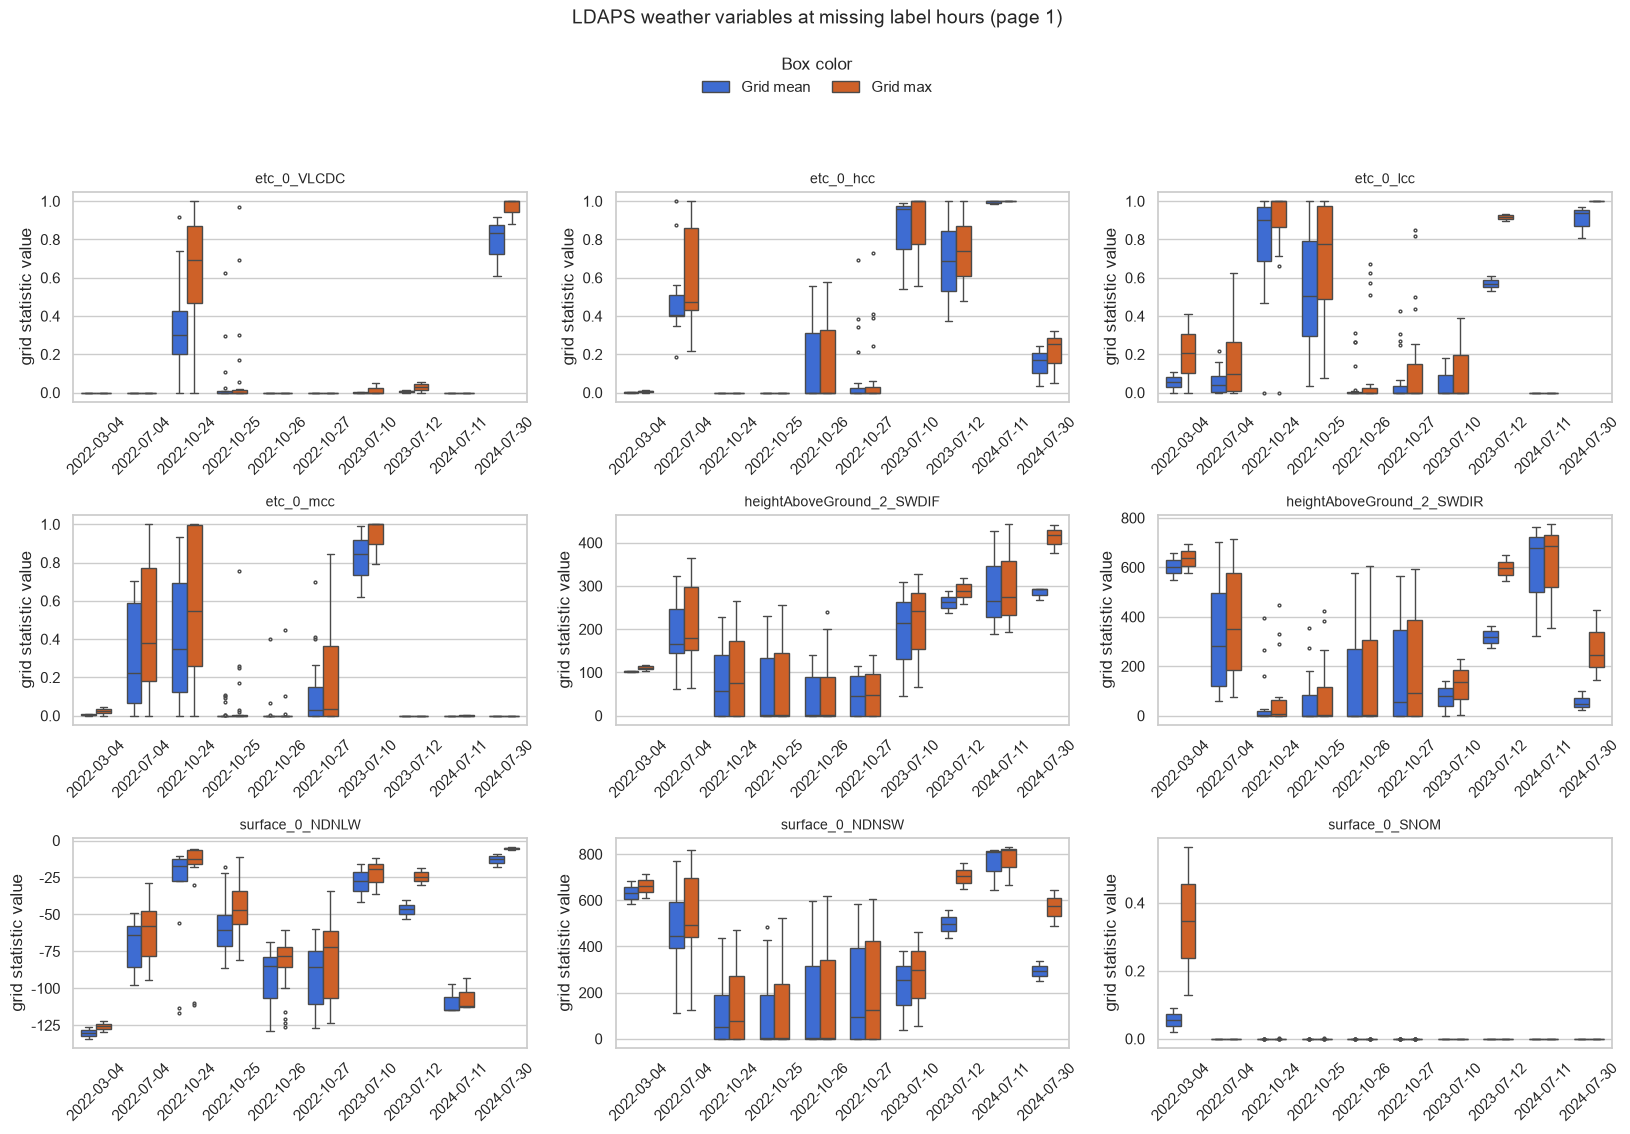

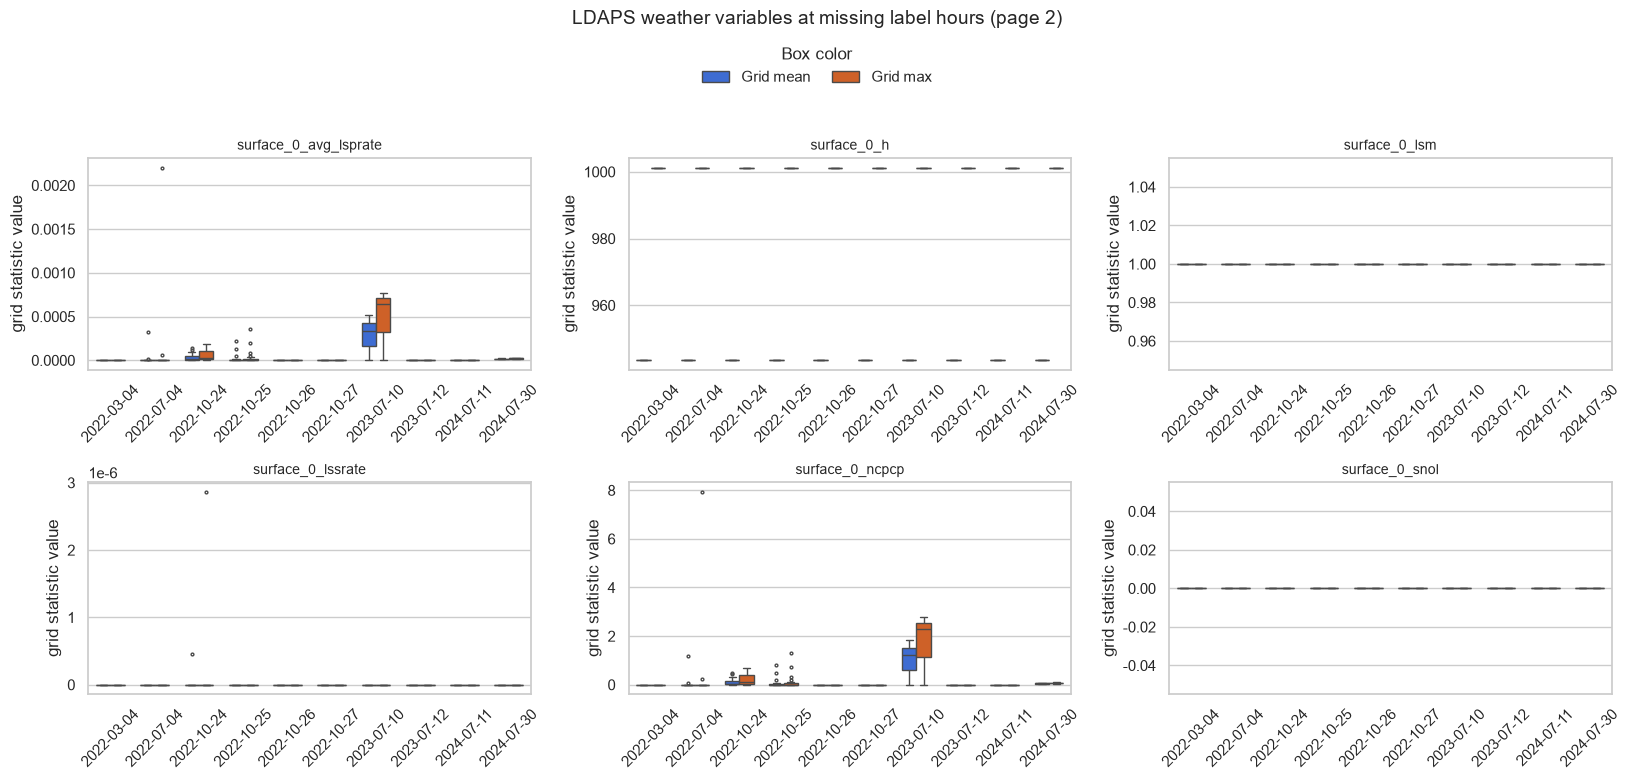

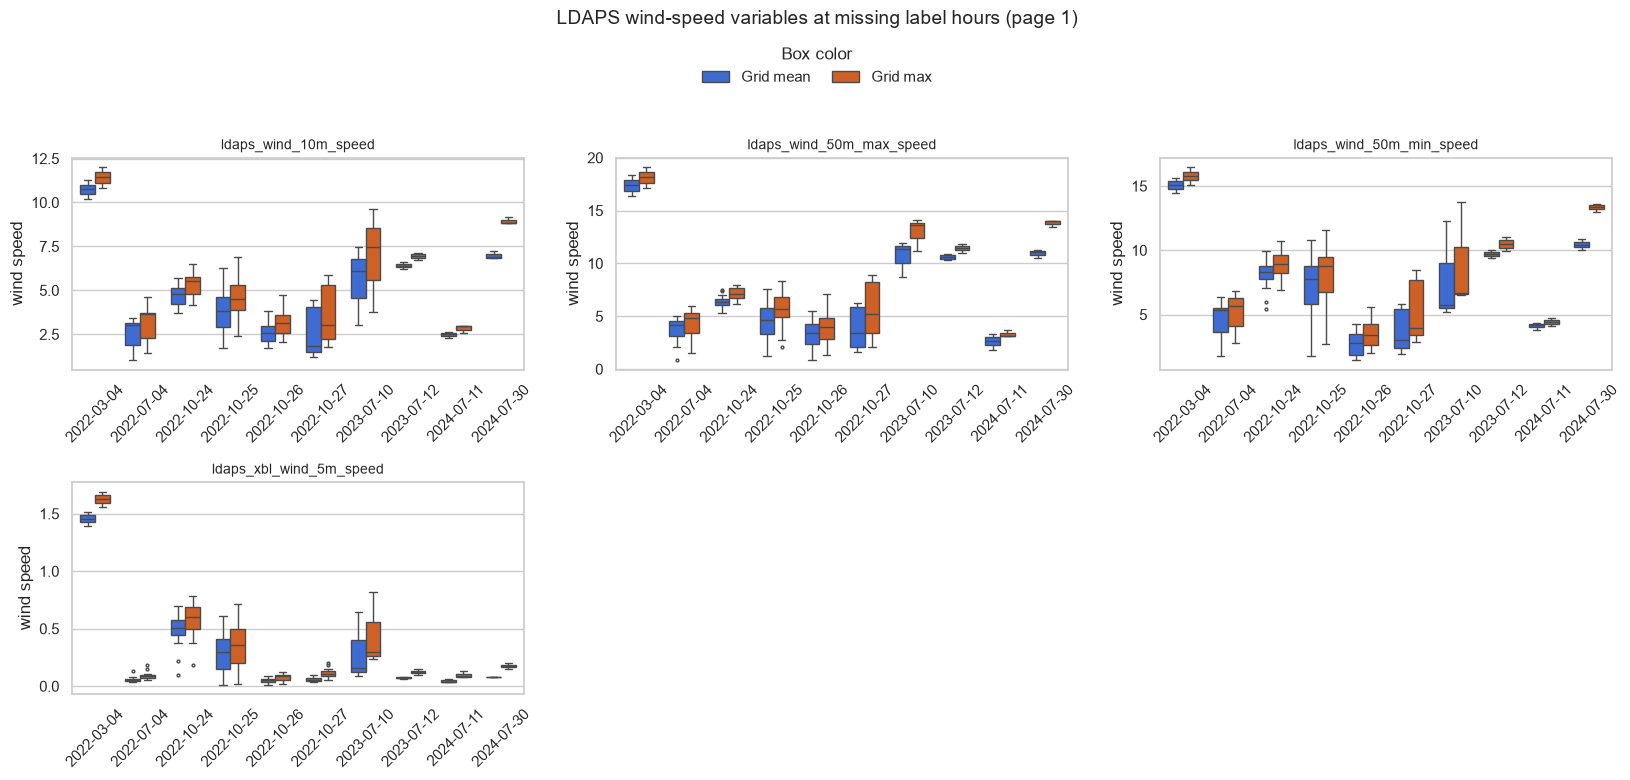

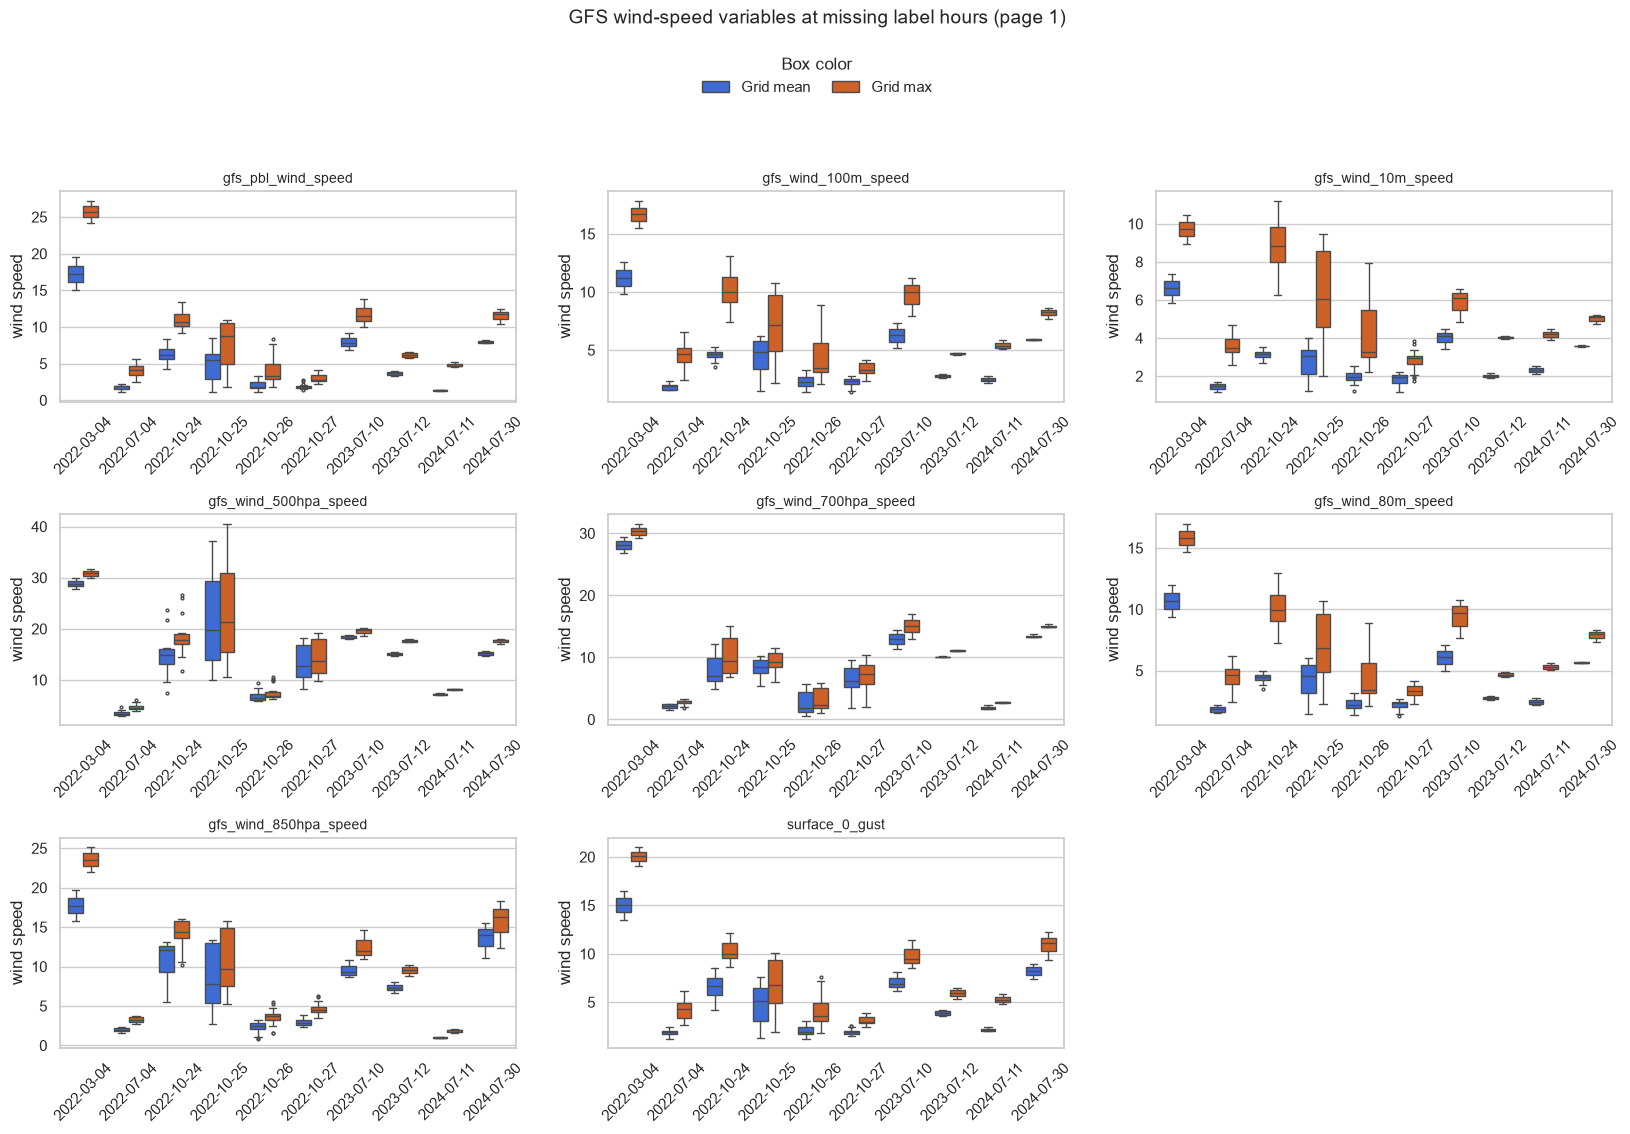

Weather/wind plot files:
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots\ldaps_weather_context_boxplot_by_missing_date_page01.png
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots\ldaps_weather_context_boxplot_by_missing_date_page02.png
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots\ldaps_wind_boxplot_by_missing_date_page01.png
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots\gfs_wind_boxplot_by_missing_date_page01.png


In [11]:

LDAPS_WEATHER_CONTEXT_VARS = [
    "surface_0_NDNSW",
    "surface_0_NDNLW",
    "heightAboveGround_2_SWDIR",
    "heightAboveGround_2_SWDIF",
    "etc_0_hcc",
    "etc_0_mcc",
    "etc_0_lcc",
    "etc_0_VLCDC",
    "surface_0_avg_lsprate",
    "surface_0_lssrate",
    "surface_0_ncpcp",
    "surface_0_snol",
    "surface_0_SNOM",
    "surface_0_lsm",
    "surface_0_h",
]

LDAPS_WIND_SPEED_SPECS = [
    ("ldaps_wind_10m_speed", "heightAboveGround_10_10u", "heightAboveGround_10_10v"),
    ("ldaps_wind_50m_max_speed", "heightAboveGround_50_50MUmax", "heightAboveGround_50_50MVmax"),
    ("ldaps_wind_50m_min_speed", "heightAboveGround_50_50MUmin", "heightAboveGround_50_50MVmin"),
    ("ldaps_xbl_wind_5m_speed", "heightAboveGround_5_XBLWS", "heightAboveGround_5_YBLWS"),
]

GFS_WIND_SPEED_SPECS = [
    ("gfs_wind_10m_speed", "heightAboveGround_10_10u", "heightAboveGround_10_10v"),
    ("gfs_wind_80m_speed", "heightAboveGround_80_u", "heightAboveGround_80_v"),
    ("gfs_wind_100m_speed", "heightAboveGround_100_100u", "heightAboveGround_100_100v"),
    ("gfs_pbl_wind_speed", "planetaryBoundaryLayer_0_u", "planetaryBoundaryLayer_0_v"),
    ("gfs_wind_850hpa_speed", "isobaricInhPa_850_u", "isobaricInhPa_850_v"),
    ("gfs_wind_700hpa_speed", "isobaricInhPa_700_u", "isobaricInhPa_700_v"),
    ("gfs_wind_500hpa_speed", "isobaricInhPa_500_u", "isobaricInhPa_500_v"),
]
GFS_DIRECT_WIND_VARS = ["surface_0_gust"]


def missing_forecast_grid_rows(weather_df: pd.DataFrame, missing_df: pd.DataFrame) -> pd.DataFrame:
    safe = latest_safe_forecast_rows(weather_df)
    missing_times = missing_df[["missing_kst_dtm"]].drop_duplicates().sort_values("missing_kst_dtm")
    rows = safe.merge(
        missing_times,
        left_on="forecast_kst_dtm",
        right_on="missing_kst_dtm",
        how="inner",
        validate="many_to_one",
    )
    rows["missing_date"] = rows["missing_kst_dtm"].dt.strftime("%Y-%m-%d")
    return rows.sort_values(["missing_kst_dtm", "grid_id"]).reset_index(drop=True)


def add_vector_speed_features(df: pd.DataFrame, speed_specs: list[tuple[str, str, str]]) -> tuple[pd.DataFrame, list[str]]:
    out = df.copy()
    added = []
    skipped = []
    for new_col, u_col, v_col in speed_specs:
        if u_col in out.columns and v_col in out.columns:
            out[new_col] = np.hypot(out[u_col], out[v_col])
            added.append(new_col)
        else:
            skipped.append((new_col, u_col, v_col))
    if skipped:
        print("Skipped unavailable wind specs:", skipped)
    return out, added


def aggregate_grid_mean_max_long(
    grid_rows: pd.DataFrame,
    source_name: str,
    variables: list[str],
    category: str,
) -> pd.DataFrame:
    available_vars = [v for v in variables if v in grid_rows.columns]
    missing_vars = [v for v in variables if v not in grid_rows.columns]
    if missing_vars:
        print(f"[{source_name}/{category}] Missing variables skipped:", missing_vars)
    if not available_vars:
        return pd.DataFrame(
            columns=["source", "category", "missing_kst_dtm", "missing_date", "variable", "statistic", "value"]
        )

    parts = []
    grouped = grid_rows.groupby("missing_kst_dtm", observed=True)
    for var in available_vars:
        part = grouped[var].agg(["mean", "max"]).reset_index()
        part = part.melt(
            id_vars="missing_kst_dtm",
            value_vars=["mean", "max"],
            var_name="statistic",
            value_name="value",
        )
        part["source"] = source_name
        part["category"] = category
        part["variable"] = var
        parts.append(part)

    out = pd.concat(parts, ignore_index=True)
    out["statistic"] = out["statistic"].map({"mean": "grid_mean", "max": "grid_max"})
    out["missing_date"] = out["missing_kst_dtm"].dt.strftime("%Y-%m-%d")
    out = out[["source", "category", "missing_kst_dtm", "missing_date", "variable", "statistic", "value"]]
    return out.sort_values(["source", "category", "variable", "missing_kst_dtm", "statistic"]).reset_index(drop=True)


def plot_boxplots_by_missing_date(
    stat_long: pd.DataFrame,
    title_prefix: str,
    output_prefix: str,
    value_label: str,
    hue_order: list[str],
    palette: dict[str, str],
    variables_per_page: int = 9,
    n_cols: int = 3,
    statistic_label_map: dict[str, str] | None = None,
) -> list[Path]:
    plot_files = []
    if stat_long.empty:
        print(f"No rows to plot for {title_prefix}.")
        return plot_files

    default_statistic_label_map = {
        "grid_mean": "Grid mean",
        "grid_max": "Grid max",
        "hourly_mean": "Hourly mean",
        "hourly_max": "Hourly max",
    }
    statistic_label_map = {**default_statistic_label_map, **(statistic_label_map or {})}

    dates = sorted(stat_long["missing_date"].dropna().unique())
    variables = list(dict.fromkeys(stat_long["variable"].dropna()))

    for page_no, start in enumerate(range(0, len(variables), variables_per_page), start=1):
        chunk = variables[start:start + variables_per_page]
        n_rows = math.ceil(len(chunk) / n_cols)
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(5.5 * n_cols, 3.6 * n_rows + 0.7),
            squeeze=False,
        )
        axes_flat = axes.ravel()
        legend_handles = None
        legend_labels = None

        for ax, variable in zip(axes_flat, chunk):
            plot_df = stat_long[stat_long["variable"] == variable].dropna(subset=["value"])
            sns.boxplot(
                data=plot_df,
                x="missing_date",
                y="value",
                hue="statistic",
                order=dates,
                hue_order=hue_order,
                palette=palette,
                width=0.65,
                dodge=True,
                fliersize=2,
                linewidth=1,
                ax=ax,
            )
            ax.set_title(variable, fontsize=10)
            ax.set_xlabel("")
            ax.set_ylabel(value_label)
            ax.tick_params(axis="x", rotation=45)
            if ax.get_legend() is not None:
                if legend_handles is None:
                    legend_handles, legend_labels = ax.get_legend_handles_labels()
                ax.get_legend().remove()

        for ax in axes_flat[len(chunk):]:
            ax.axis("off")

        fig.suptitle(f"{title_prefix} (page {page_no})", y=0.985, fontsize=14)
        if legend_handles:
            readable_legend_labels = [statistic_label_map.get(label, label) for label in legend_labels]
            fig.legend(
                legend_handles,
                readable_legend_labels,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.955),
                ncol=len(hue_order),
                frameon=False,
                title="Box color",
                handlelength=1.8,
                columnspacing=1.4,
            )
        fig.tight_layout(rect=[0, 0, 1, 0.89])

        out_path = PLOT_DIR / f"{output_prefix}_page{page_no:02d}.png"
        fig.savefig(out_path, dpi=160, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        plot_files.append(out_path)

    return plot_files


missing_date_summary = (
    missing_label_times
    .assign(missing_date=missing_label_times["missing_kst_dtm"].dt.strftime("%Y-%m-%d"))
    .groupby("missing_date", as_index=False)
    .agg(
        n_missing_events=("missing_kst_dtm", "count"),
        n_unique_missing_hours=("missing_kst_dtm", "nunique"),
        groups=("group", lambda s: ", ".join(sorted(s.unique()))),
    )
)
display(missing_date_summary)

ldaps_missing_grid_rows = missing_forecast_grid_rows(ldaps, missing_label_times)
gfs_missing_grid_rows = missing_forecast_grid_rows(gfs, missing_label_times)

missing_ldaps_weather_context_stats = aggregate_grid_mean_max_long(
    ldaps_missing_grid_rows,
    "ldaps",
    LDAPS_WEATHER_CONTEXT_VARS,
    "weather_context",
)

ldaps_wind_grid_rows, ldaps_wind_vars = add_vector_speed_features(ldaps_missing_grid_rows, LDAPS_WIND_SPEED_SPECS)
gfs_wind_grid_rows, gfs_wind_derived_vars = add_vector_speed_features(gfs_missing_grid_rows, GFS_WIND_SPEED_SPECS)
gfs_wind_vars = gfs_wind_derived_vars + [v for v in GFS_DIRECT_WIND_VARS if v in gfs_wind_grid_rows.columns]

missing_ldaps_wind_stats = aggregate_grid_mean_max_long(
    ldaps_wind_grid_rows,
    "ldaps",
    ldaps_wind_vars,
    "wind_speed",
)
missing_gfs_wind_stats = aggregate_grid_mean_max_long(
    gfs_wind_grid_rows,
    "gfs",
    gfs_wind_vars,
    "wind_speed",
)

missing_ldaps_weather_context_stats.to_csv(OUTPUT_PATHS["ldaps_weather_context_stats"], index=False, encoding="utf-8-sig")
missing_ldaps_wind_stats.to_csv(OUTPUT_PATHS["ldaps_wind_stats"], index=False, encoding="utf-8-sig")
missing_gfs_wind_stats.to_csv(OUTPUT_PATHS["gfs_wind_stats"], index=False, encoding="utf-8-sig")

print("LDAPS weather context stats:", missing_ldaps_weather_context_stats.shape)
print("LDAPS wind stats:", missing_ldaps_wind_stats.shape)
print("GFS wind stats:", missing_gfs_wind_stats.shape)
print("Saved:", OUTPUT_PATHS["ldaps_weather_context_stats"])
print("Saved:", OUTPUT_PATHS["ldaps_wind_stats"])
print("Saved:", OUTPUT_PATHS["gfs_wind_stats"])

weather_plot_files = []
weather_plot_files += plot_boxplots_by_missing_date(
    missing_ldaps_weather_context_stats,
    title_prefix="LDAPS weather variables at missing label hours",
    output_prefix="ldaps_weather_context_boxplot_by_missing_date",
    value_label="grid statistic value",
    hue_order=["grid_mean", "grid_max"],
    palette={"grid_mean": "#2563eb", "grid_max": "#ea580c"},
)
weather_plot_files += plot_boxplots_by_missing_date(
    missing_ldaps_wind_stats,
    title_prefix="LDAPS wind-speed variables at missing label hours",
    output_prefix="ldaps_wind_boxplot_by_missing_date",
    value_label="wind speed",
    hue_order=["grid_mean", "grid_max"],
    palette={"grid_mean": "#2563eb", "grid_max": "#ea580c"},
)
weather_plot_files += plot_boxplots_by_missing_date(
    missing_gfs_wind_stats,
    title_prefix="GFS wind-speed variables at missing label hours",
    output_prefix="gfs_wind_boxplot_by_missing_date",
    value_label="wind speed",
    hue_order=["grid_mean", "grid_max"],
    palette={"grid_mean": "#2563eb", "grid_max": "#ea580c"},
)

print("Weather/wind plot files:")
for path in weather_plot_files:
    print("-", path)


## 8. Missing-Date SCADA Wind-Speed Visualizations


SCADA hourly wind stats: (2544, 9)
Saved: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_scada_hourly_wind_stats_long.csv


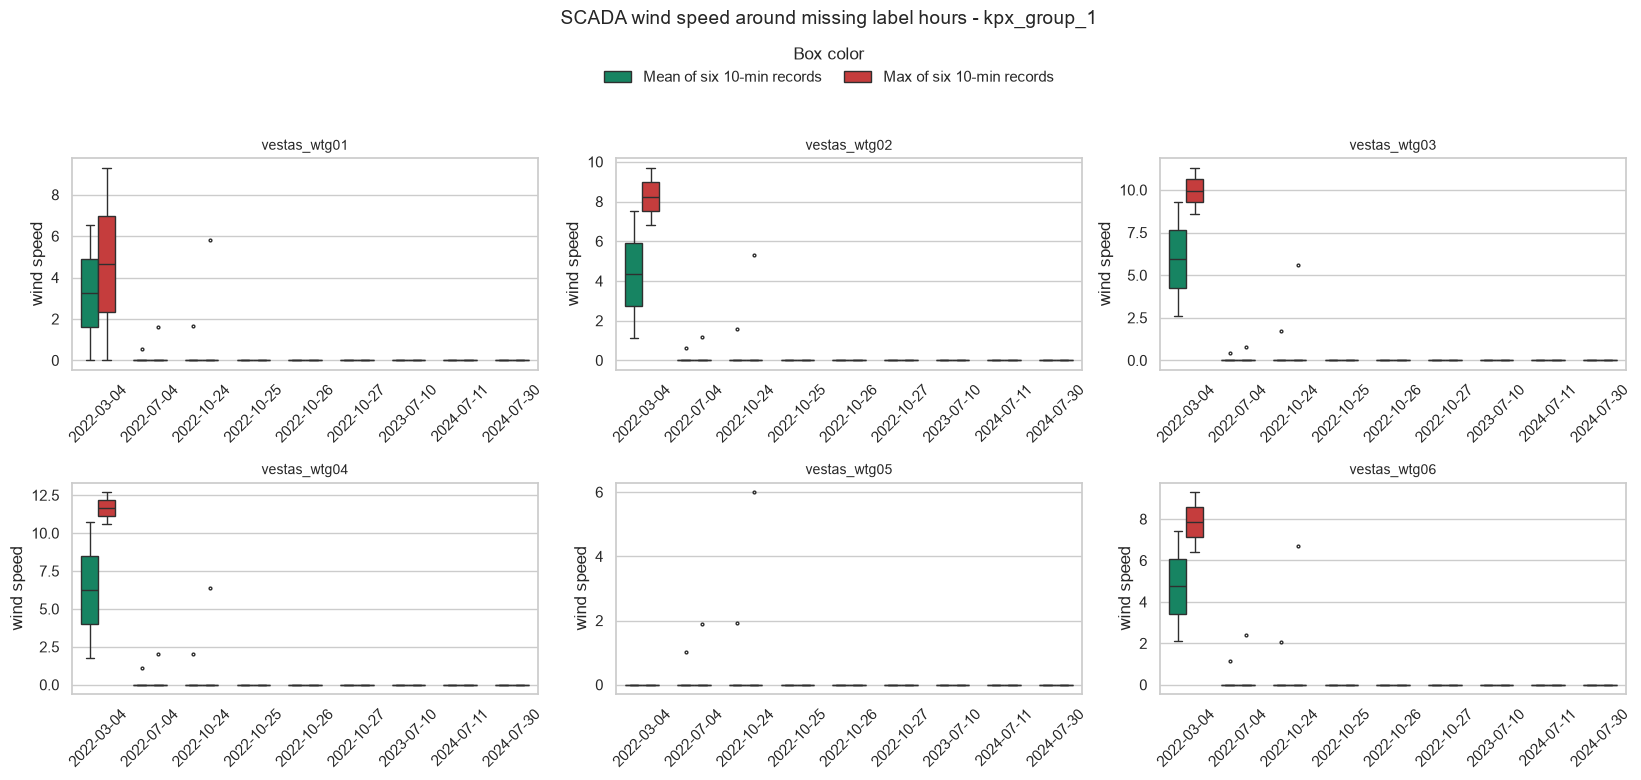

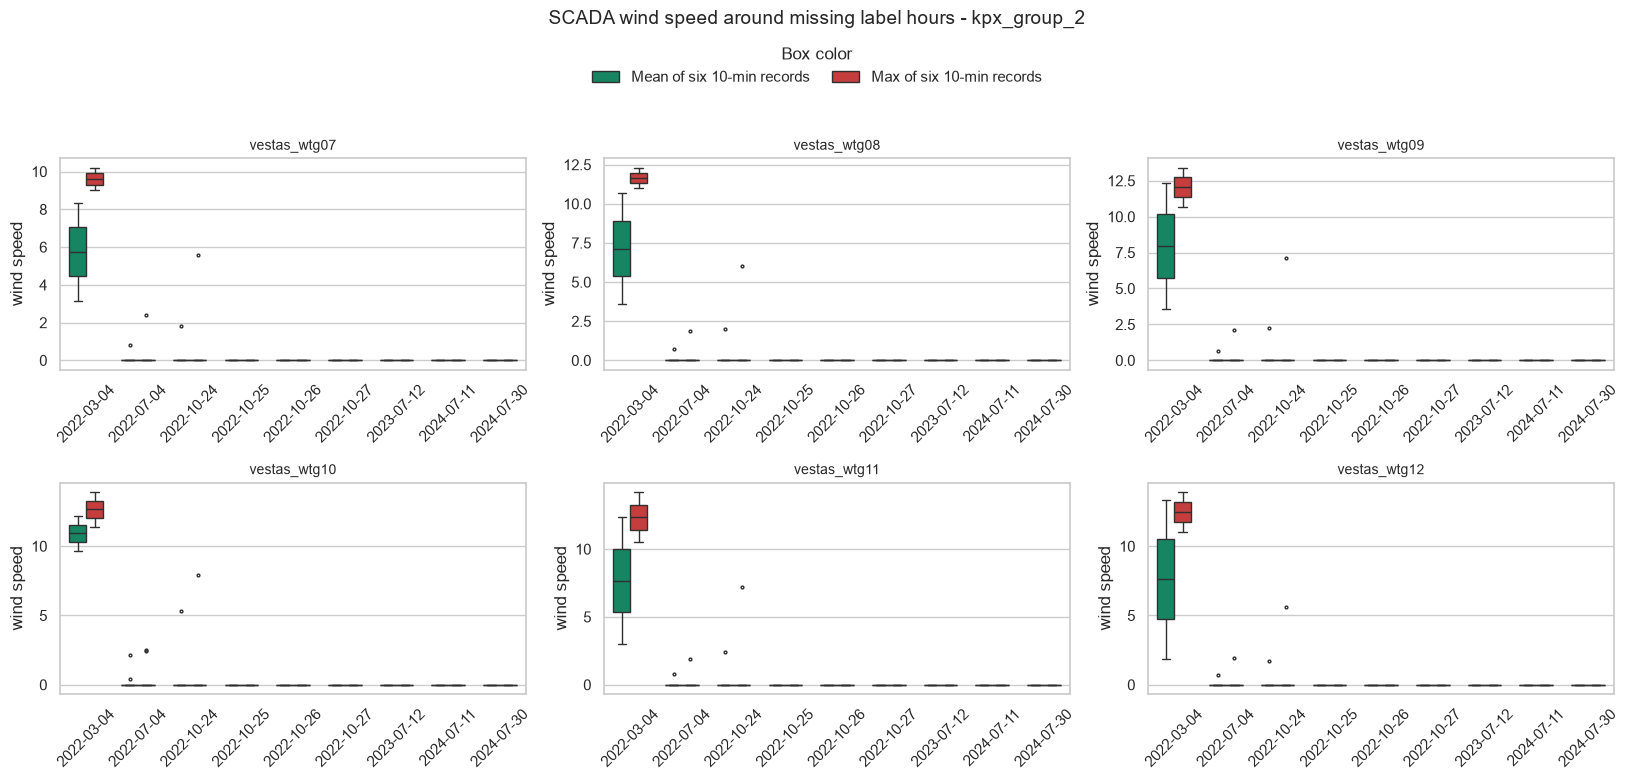

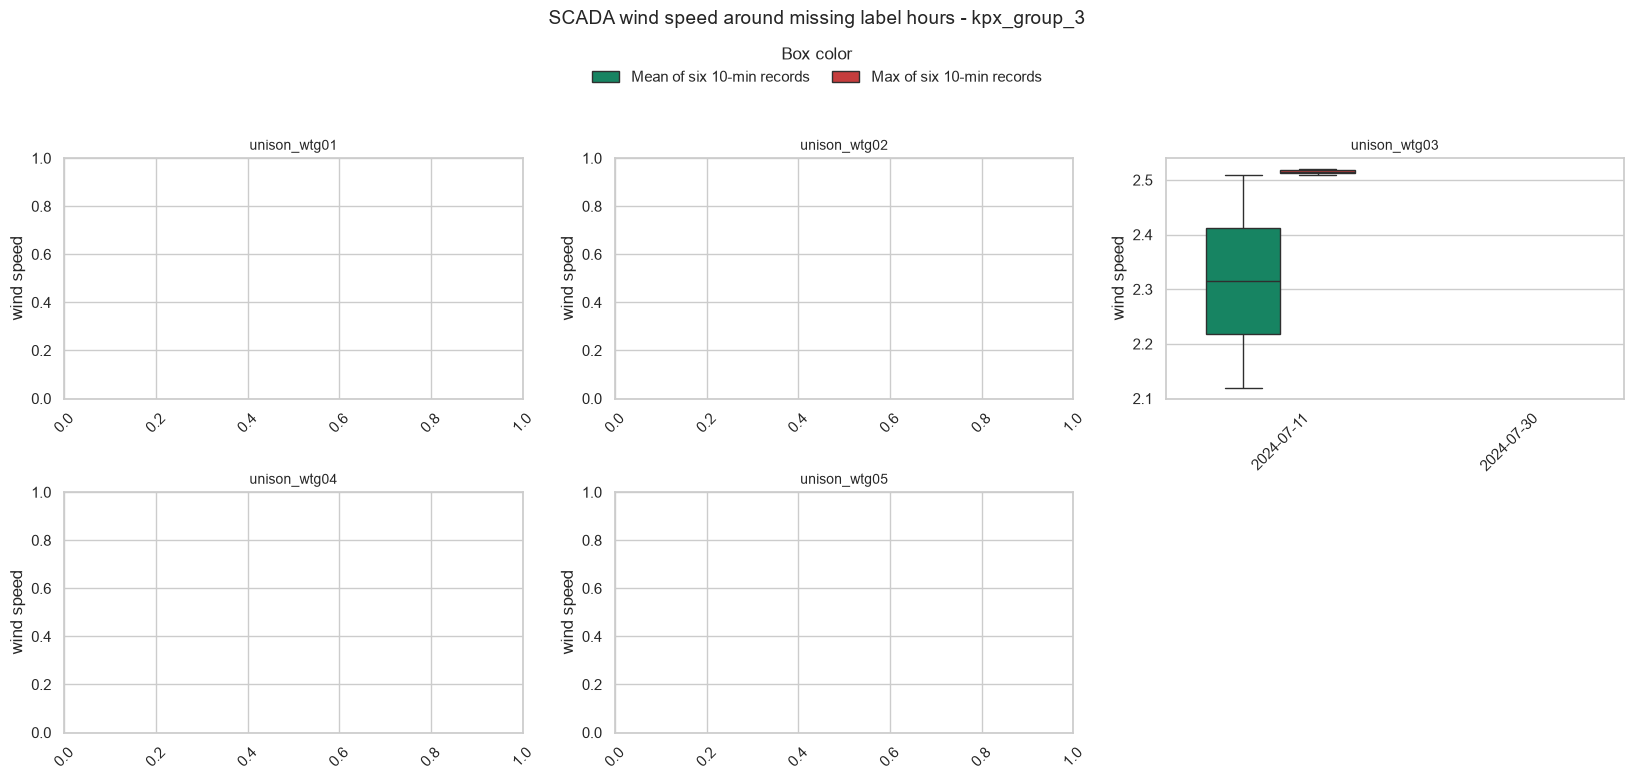

SCADA plot files:
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots\scada_wind_speed_boxplot_by_missing_date_kpx_group_1.png
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots\scada_wind_speed_boxplot_by_missing_date_kpx_group_2.png
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots\scada_wind_speed_boxplot_by_missing_date_kpx_group_3.png


In [12]:

def make_scada_hourly_wind_stats(scada_rows: pd.DataFrame) -> pd.DataFrame:
    if scada_rows.empty:
        return pd.DataFrame(
            columns=[
                "group",
                "source",
                "turbine_no",
                "turbine_id",
                "missing_kst_dtm",
                "missing_date",
                "n_10min_rows",
                "statistic",
                "value",
            ]
        )

    hourly = (
        scada_rows
        .groupby(["group", "source", "turbine_no", "turbine_id", "missing_kst_dtm"], as_index=False)
        .agg(
            n_10min_rows=("kst_dtm", "count"),
            wind_speed_mean=("wind_speed", "mean"),
            wind_speed_max=("wind_speed", "max"),
        )
    )
    hourly["missing_date"] = hourly["missing_kst_dtm"].dt.strftime("%Y-%m-%d")

    long = hourly.melt(
        id_vars=["group", "source", "turbine_no", "turbine_id", "missing_kst_dtm", "missing_date", "n_10min_rows"],
        value_vars=["wind_speed_mean", "wind_speed_max"],
        var_name="statistic",
        value_name="value",
    )
    long["statistic"] = long["statistic"].map(
        {"wind_speed_mean": "hourly_mean", "wind_speed_max": "hourly_max"}
    )
    return long.sort_values(["group", "turbine_no", "missing_kst_dtm", "statistic"]).reset_index(drop=True)


def plot_scada_wind_by_group_turbine(scada_stat_long: pd.DataFrame) -> list[Path]:
    plot_files = []
    if scada_stat_long.empty:
        print("No SCADA wind rows to plot.")
        return plot_files

    hue_order = ["hourly_mean", "hourly_max"]
    palette = {"hourly_mean": "#059669", "hourly_max": "#dc2626"}
    statistic_label_map = {
        "hourly_mean": "Mean of six 10-min records",
        "hourly_max": "Max of six 10-min records",
    }

    for group, group_df in scada_stat_long.groupby("group", sort=True):
        dates = sorted(group_df["missing_date"].dropna().unique())
        turbines = group_df[["turbine_no", "turbine_id"]].drop_duplicates().sort_values("turbine_no")
        n_cols = 3
        n_rows = math.ceil(len(turbines) / n_cols)
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(5.5 * n_cols, 3.6 * n_rows + 0.7),
            squeeze=False,
        )
        axes_flat = axes.ravel()
        legend_handles = None
        legend_labels = None

        for ax, row in zip(axes_flat, turbines.itertuples(index=False)):
            turbine_df = group_df[group_df["turbine_id"] == row.turbine_id].dropna(subset=["value"])
            sns.boxplot(
                data=turbine_df,
                x="missing_date",
                y="value",
                hue="statistic",
                order=dates,
                hue_order=hue_order,
                palette=palette,
                width=0.65,
                dodge=True,
                fliersize=2,
                linewidth=1,
                ax=ax,
            )
            ax.set_title(row.turbine_id, fontsize=10)
            ax.set_xlabel("")
            ax.set_ylabel("wind speed")
            ax.tick_params(axis="x", rotation=45)
            if ax.get_legend() is not None:
                if legend_handles is None:
                    legend_handles, legend_labels = ax.get_legend_handles_labels()
                ax.get_legend().remove()

        for ax in axes_flat[len(turbines):]:
            ax.axis("off")

        fig.suptitle(f"SCADA wind speed around missing label hours - {group}", y=0.985, fontsize=14)
        if legend_handles:
            readable_legend_labels = [statistic_label_map.get(label, label) for label in legend_labels]
            fig.legend(
                legend_handles,
                readable_legend_labels,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.955),
                ncol=len(hue_order),
                frameon=False,
                title="Box color",
                handlelength=1.8,
                columnspacing=1.4,
            )
        fig.tight_layout(rect=[0, 0, 1, 0.89])

        out_path = PLOT_DIR / f"scada_wind_speed_boxplot_by_missing_date_{group}.png"
        fig.savefig(out_path, dpi=160, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        plot_files.append(out_path)

    return plot_files


missing_scada_hourly_wind_stats = make_scada_hourly_wind_stats(missing_scada_10min)
missing_scada_hourly_wind_stats.to_csv(OUTPUT_PATHS["scada_hourly_wind_stats"], index=False, encoding="utf-8-sig")

print("SCADA hourly wind stats:", missing_scada_hourly_wind_stats.shape)
print("Saved:", OUTPUT_PATHS["scada_hourly_wind_stats"])

scada_plot_files = plot_scada_wind_by_group_turbine(missing_scada_hourly_wind_stats)

print("SCADA plot files:")
for path in scada_plot_files:
    print("-", path)


## 9. SCADA Wind-Direction EDA

### 9.1 Hourly, Monthly, and Seasonal Turbine-Level Distributions


SCADA wind-direction long rows: (2420148, 14)
Rows with valid wind_direction: 2417947
Hourly summary: (408, 14)
Monthly summary: (204, 14)
Seasonal summary: (68, 14)


,group,source,turbine_no,turbine_id,hour,n_obs,mean_wind_speed,median_wind_speed,circular_mean_direction_deg,resultant_length,circular_std_deg,dominant_sector,dominant_sector_count,dominant_sector_share
0,kpx_group_1,vestas,1,vestas_wtg01,0,6571,7.775868,7.477,265.822854,0.503848,67.086536,WSW,1557,0.236950
1,kpx_group_1,vestas,1,vestas_wtg01,1,6576,7.761498,7.600,267.917867,0.505057,66.969165,W,1637,0.248936
2,kpx_group_1,vestas,1,vestas_wtg01,2,6576,7.793865,7.629,270.527372,0.499215,67.537000,W,1651,0.251064
3,kpx_group_1,vestas,1,vestas_wtg01,3,6576,7.829812,7.582,273.168829,0.493329,68.111126,W,1697,0.258060
4,kpx_group_1,vestas,1,vestas_wtg01,4,6576,7.782607,7.498,275.336022,0.482229,69.199220,W,1672,0.254258


,group,source,turbine_no,turbine_id,month,n_obs,mean_wind_speed,median_wind_speed,circular_mean_direction_deg,resultant_length,circular_std_deg,dominant_sector,dominant_sector_count,dominant_sector_share
0,kpx_group_1,vestas,1,vestas_wtg01,1,13387,8.855973,8.887,279.213636,0.704177,47.986728,W,4626,0.345559
1,kpx_group_1,vestas,1,vestas_wtg01,2,12240,7.663680,7.000,295.998558,0.463890,71.014758,NW,2892,0.236275
2,kpx_group_1,vestas,1,vestas_wtg01,3,13392,7.479724,7.051,275.681162,0.531226,64.445262,WSW,3082,0.230137
3,kpx_group_1,vestas,1,vestas_wtg01,4,12960,7.178444,6.648,289.384859,0.295236,89.498181,NW,2364,0.182407
4,kpx_group_1,vestas,1,vestas_wtg01,5,13392,7.071993,6.762,284.053130,0.470648,70.343020,W,2592,0.193548


,group,source,turbine_no,turbine_id,season,n_obs,mean_wind_speed,median_wind_speed,circular_mean_direction_deg,resultant_length,circular_std_deg,dominant_sector,dominant_sector_count,dominant_sector_share
0,kpx_group_1,vestas,1,vestas_wtg01,Winter(DJF),39019,8.827022,8.848,279.702949,0.627343,55.328927,W,12524,0.320972
1,kpx_group_1,vestas,1,vestas_wtg01,Spring(MAM),39744,7.244093,6.813,281.781748,0.431876,74.246890,W,7911,0.199049
2,kpx_group_1,vestas,1,vestas_wtg01,Summer(JJA),39744,5.954425,5.300,241.093877,0.344789,83.613475,WSW,11524,0.289956
3,kpx_group_1,vestas,1,vestas_wtg01,Autumn(SON),39312,6.189278,5.400,268.541583,0.239547,96.862324,WSW,9000,0.228938
4,kpx_group_1,vestas,2,vestas_wtg02,Winter(DJF),39019,8.908956,8.800,263.083944,0.698200,48.566366,W,18806,0.481970


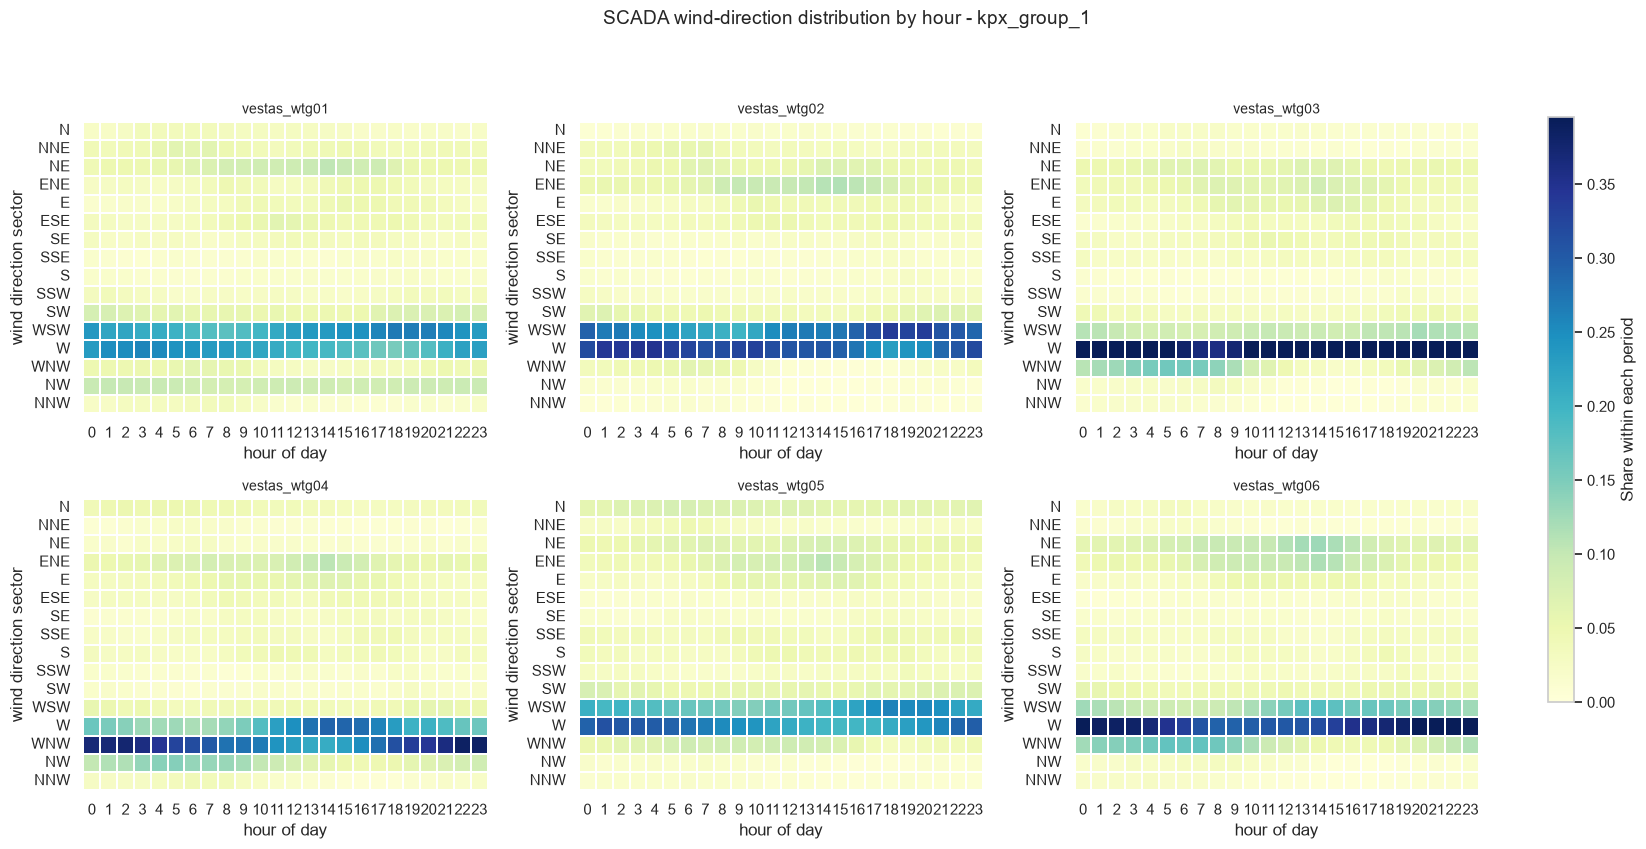

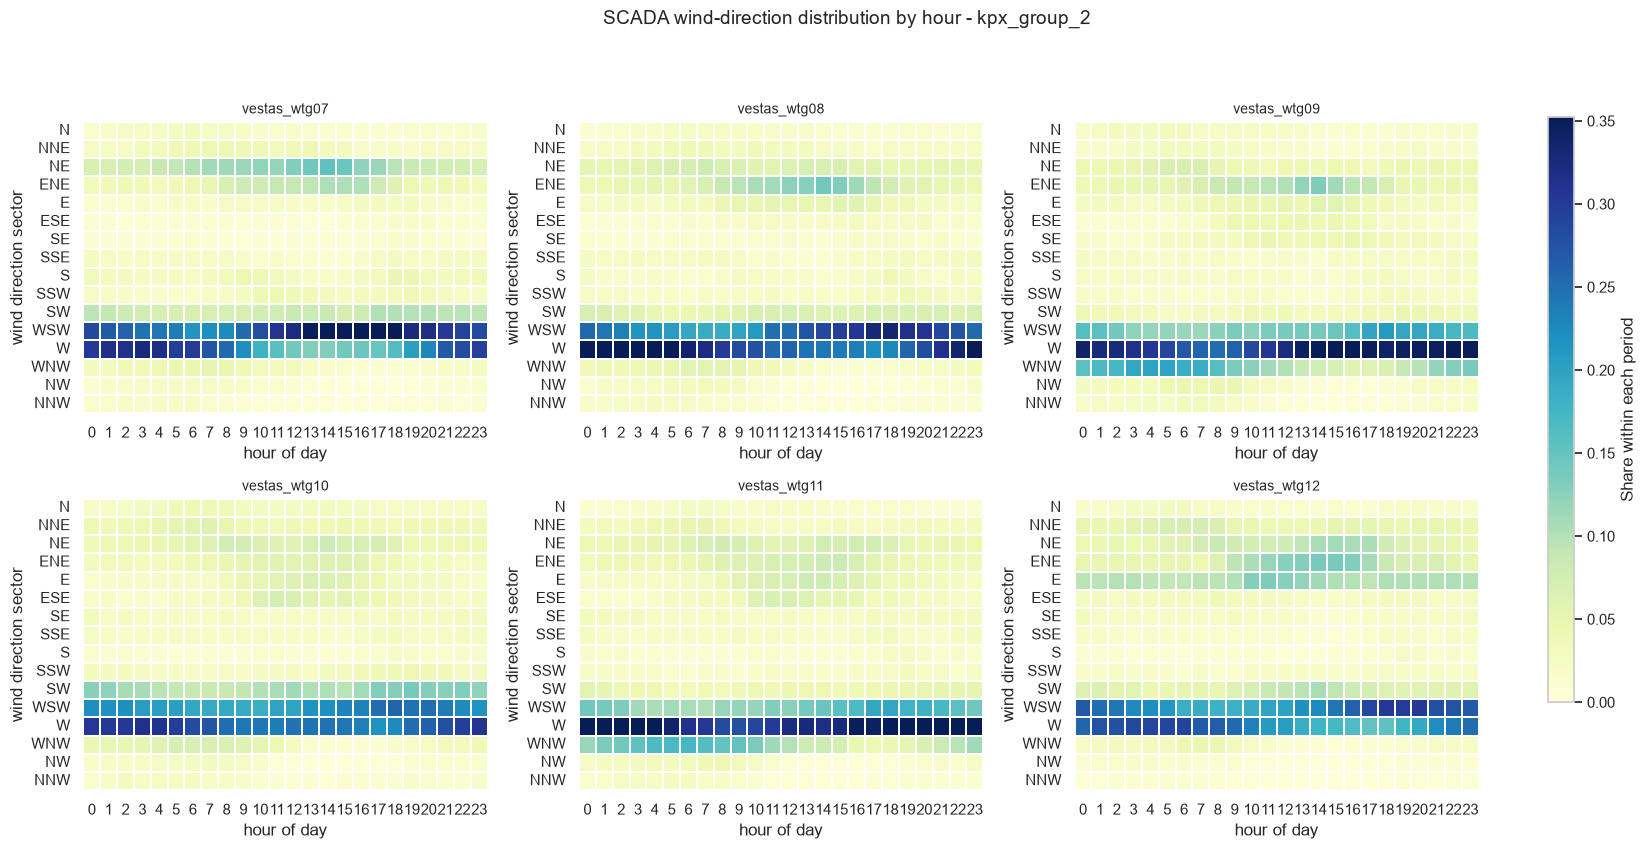

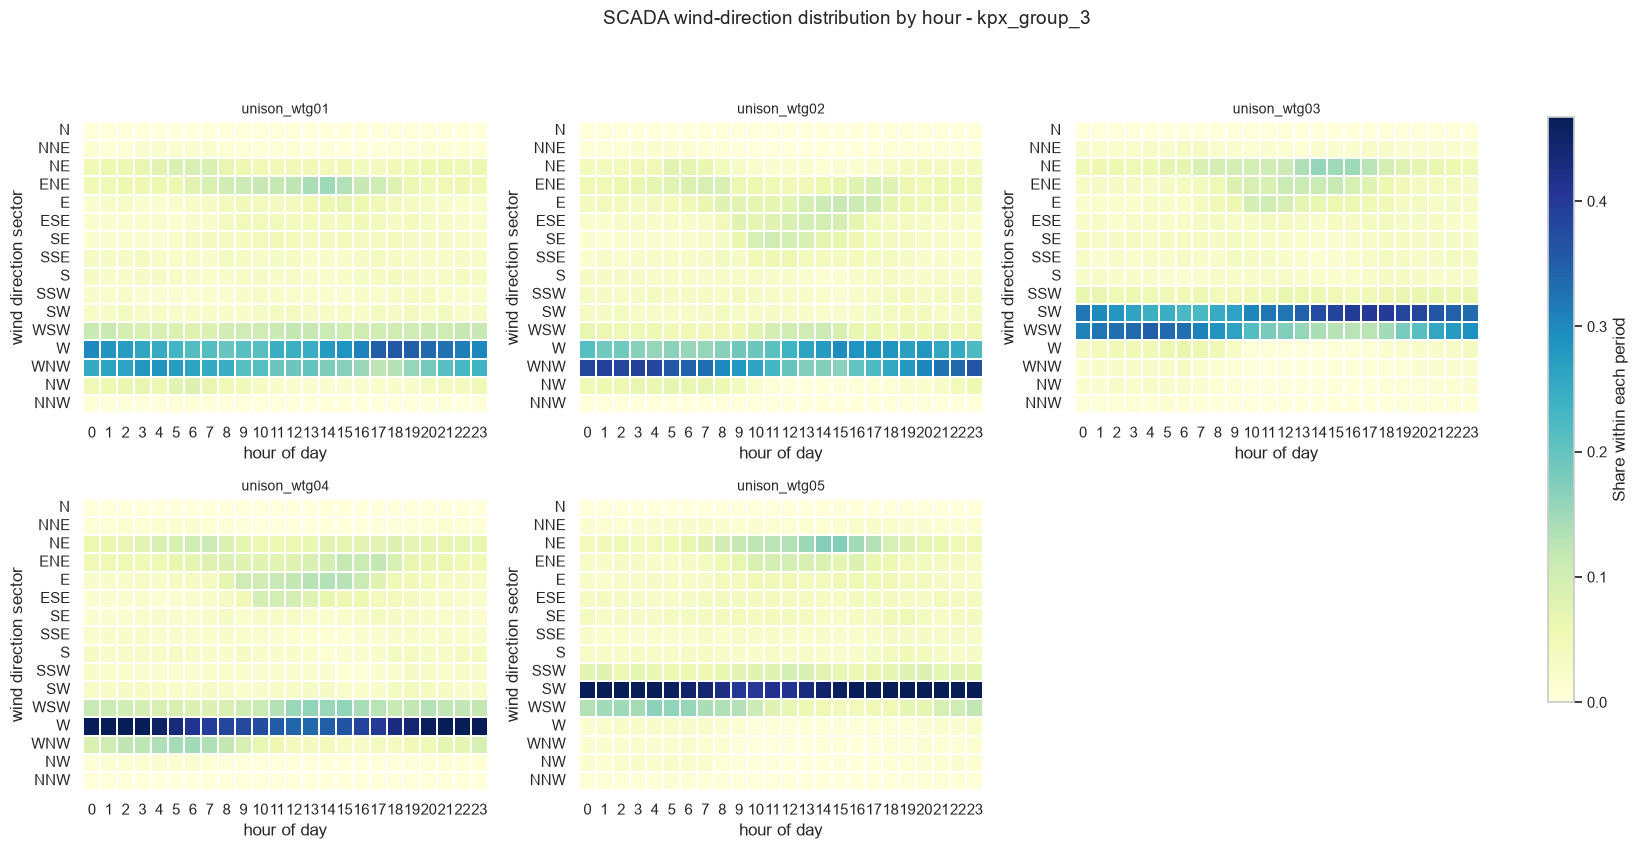

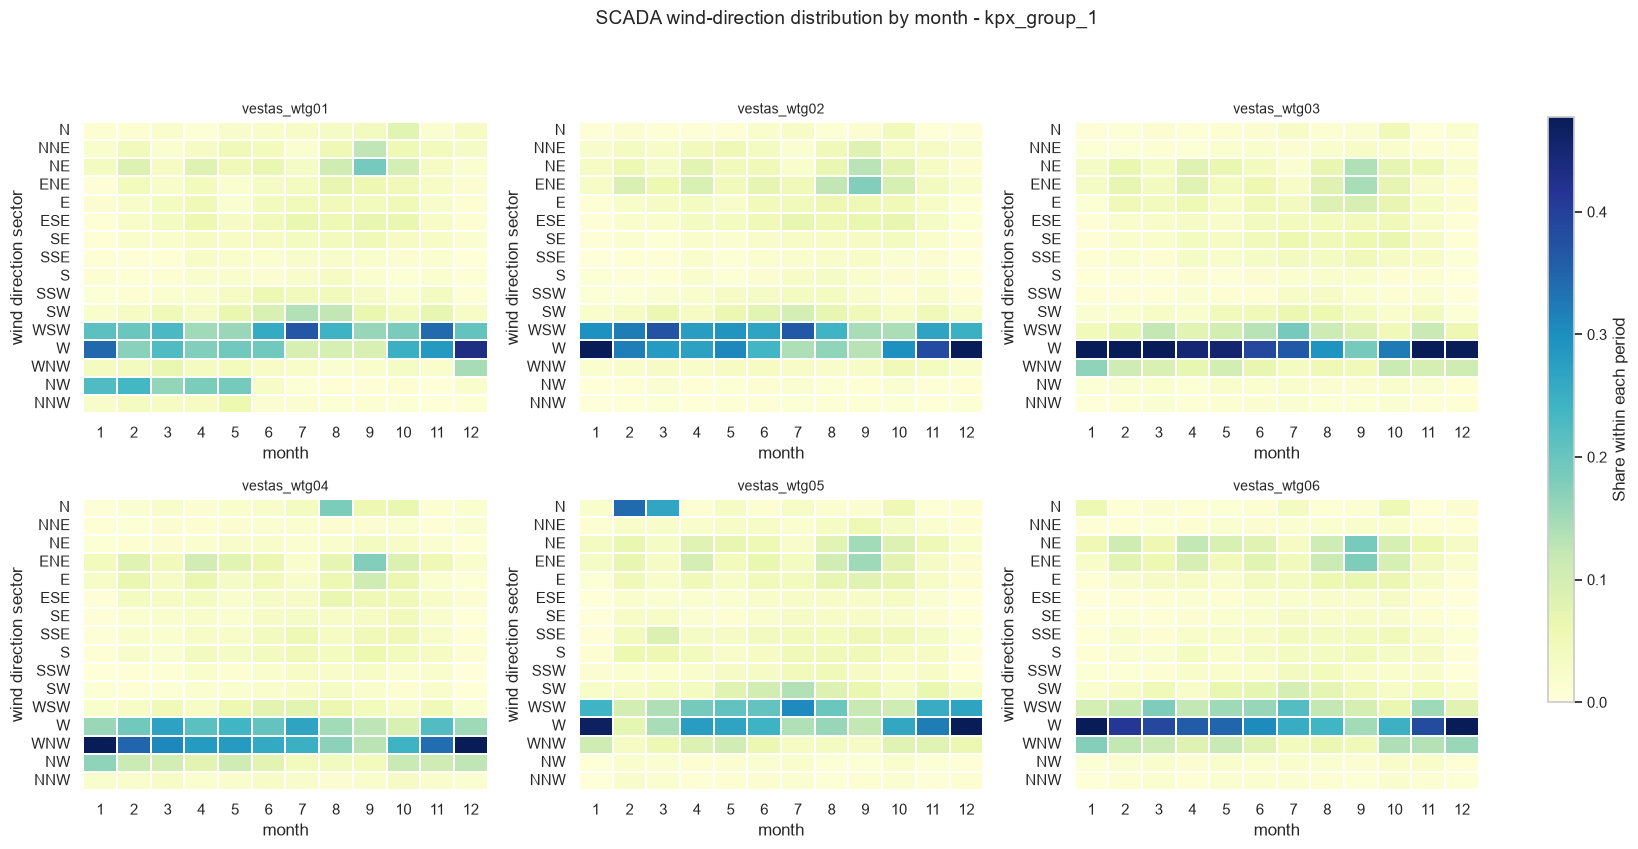

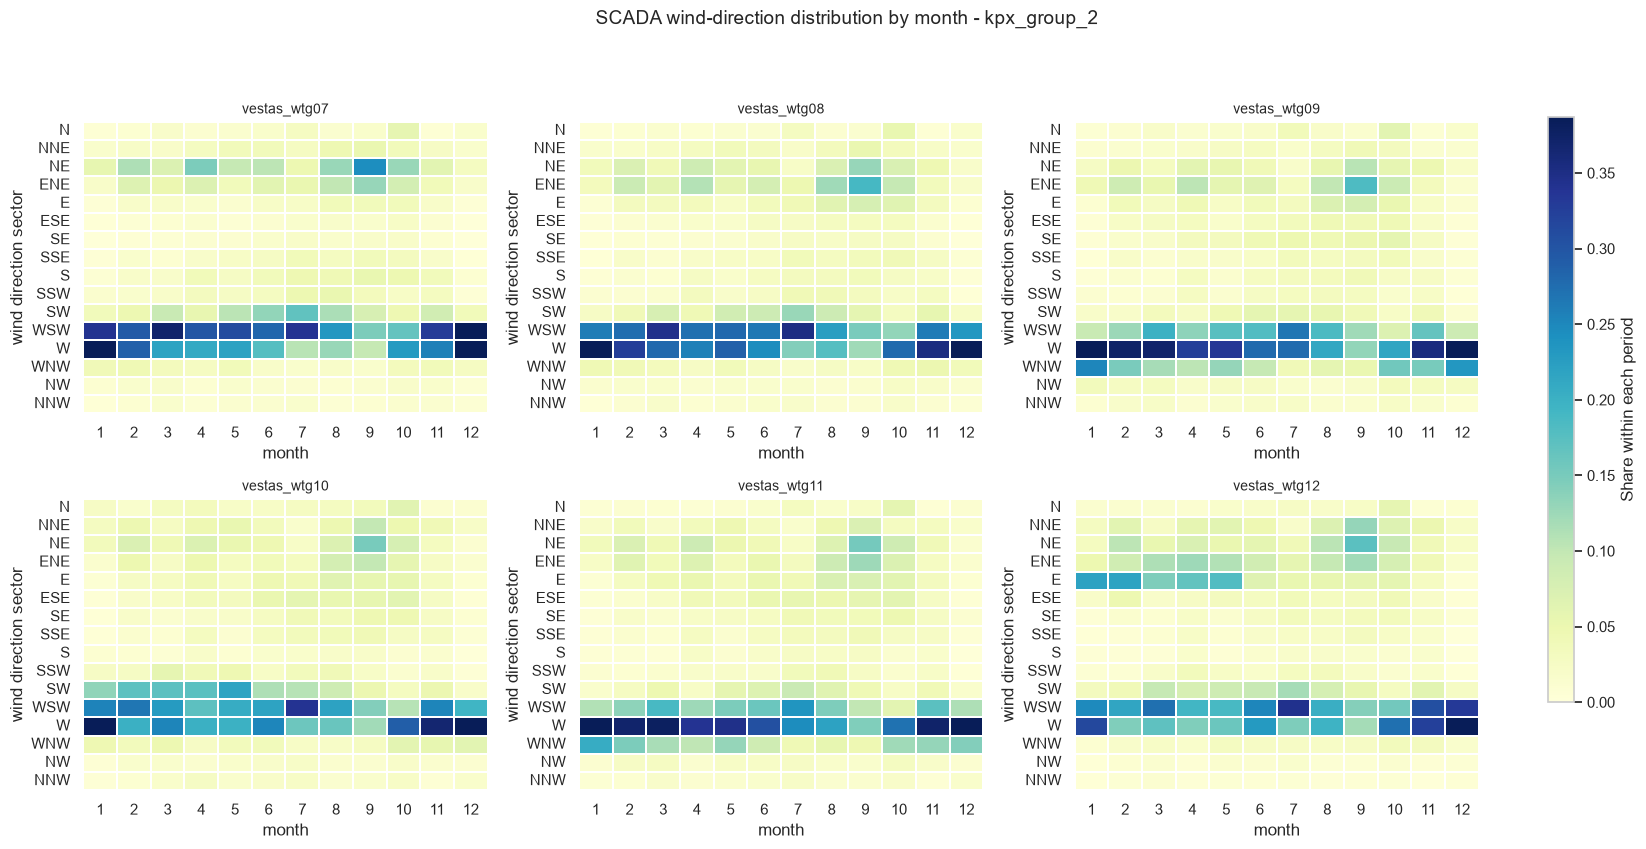

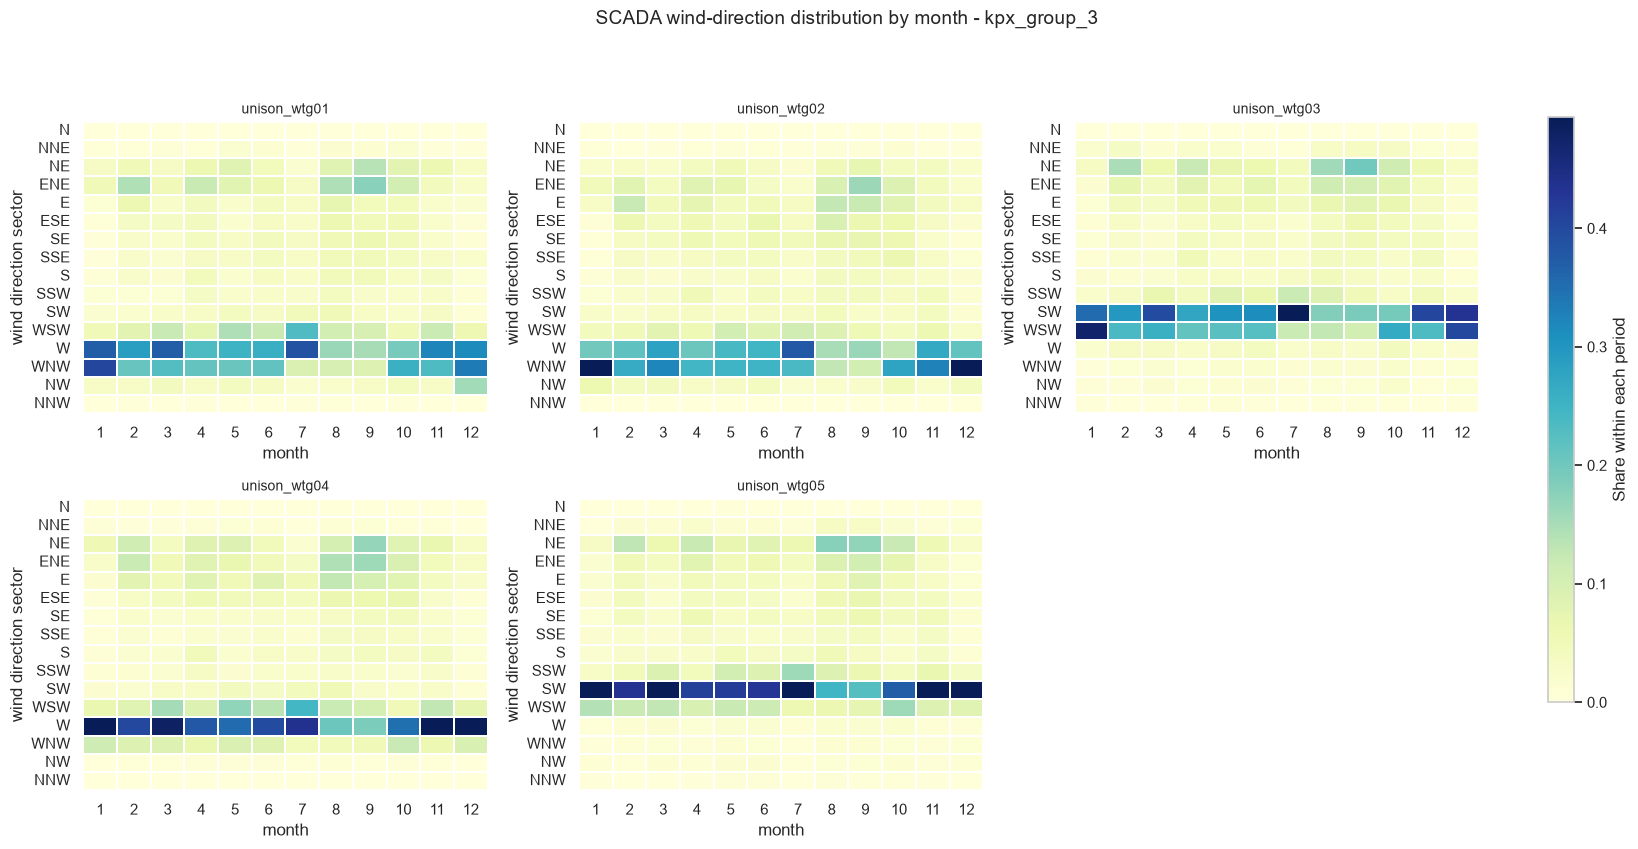

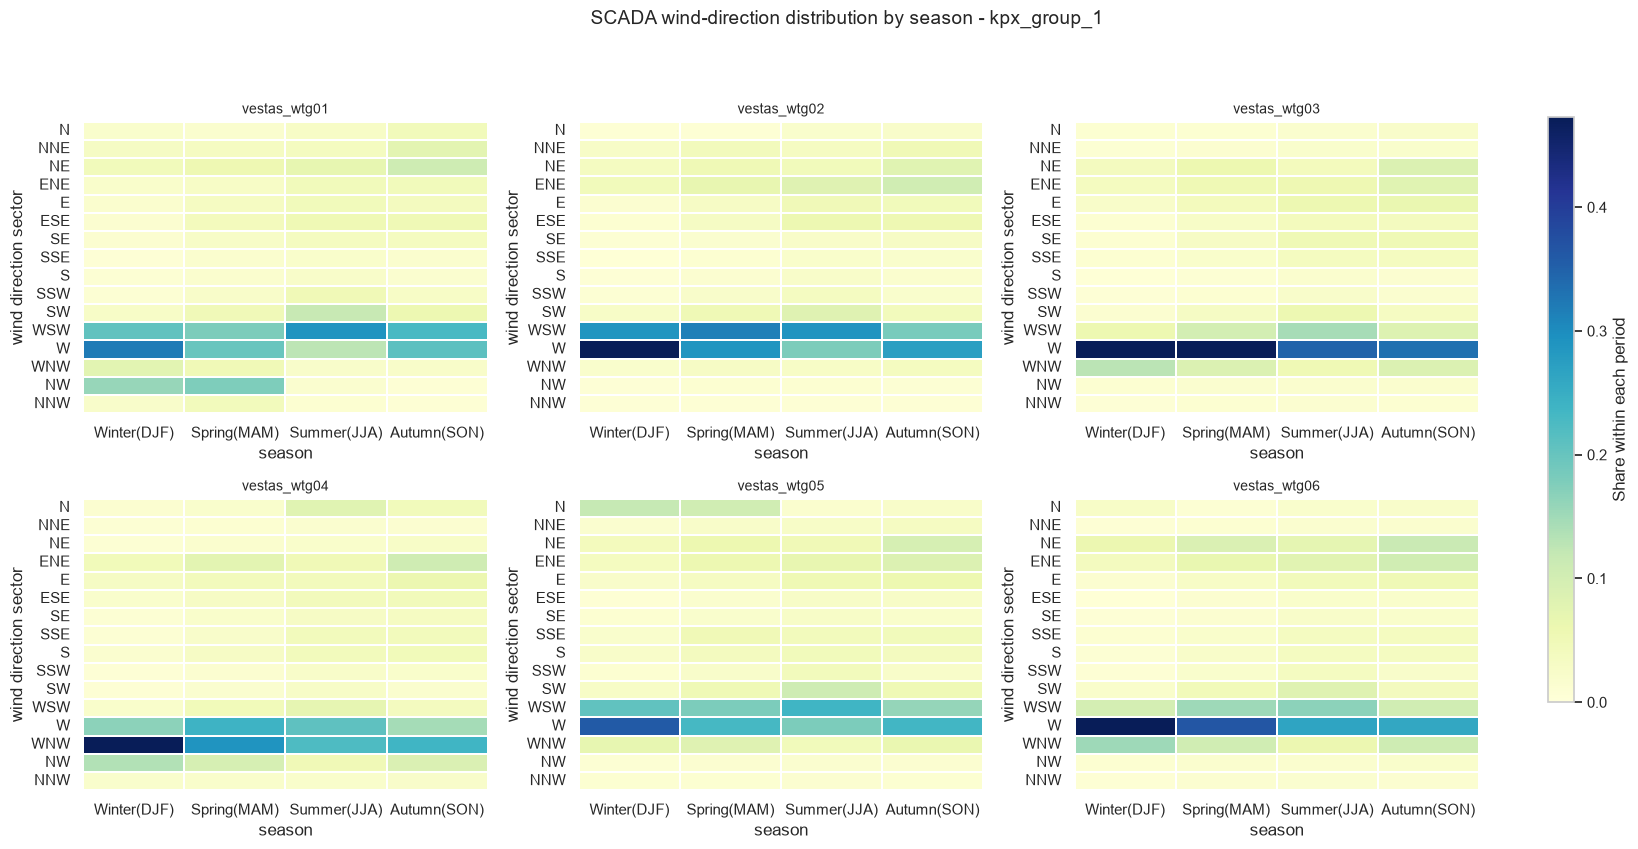

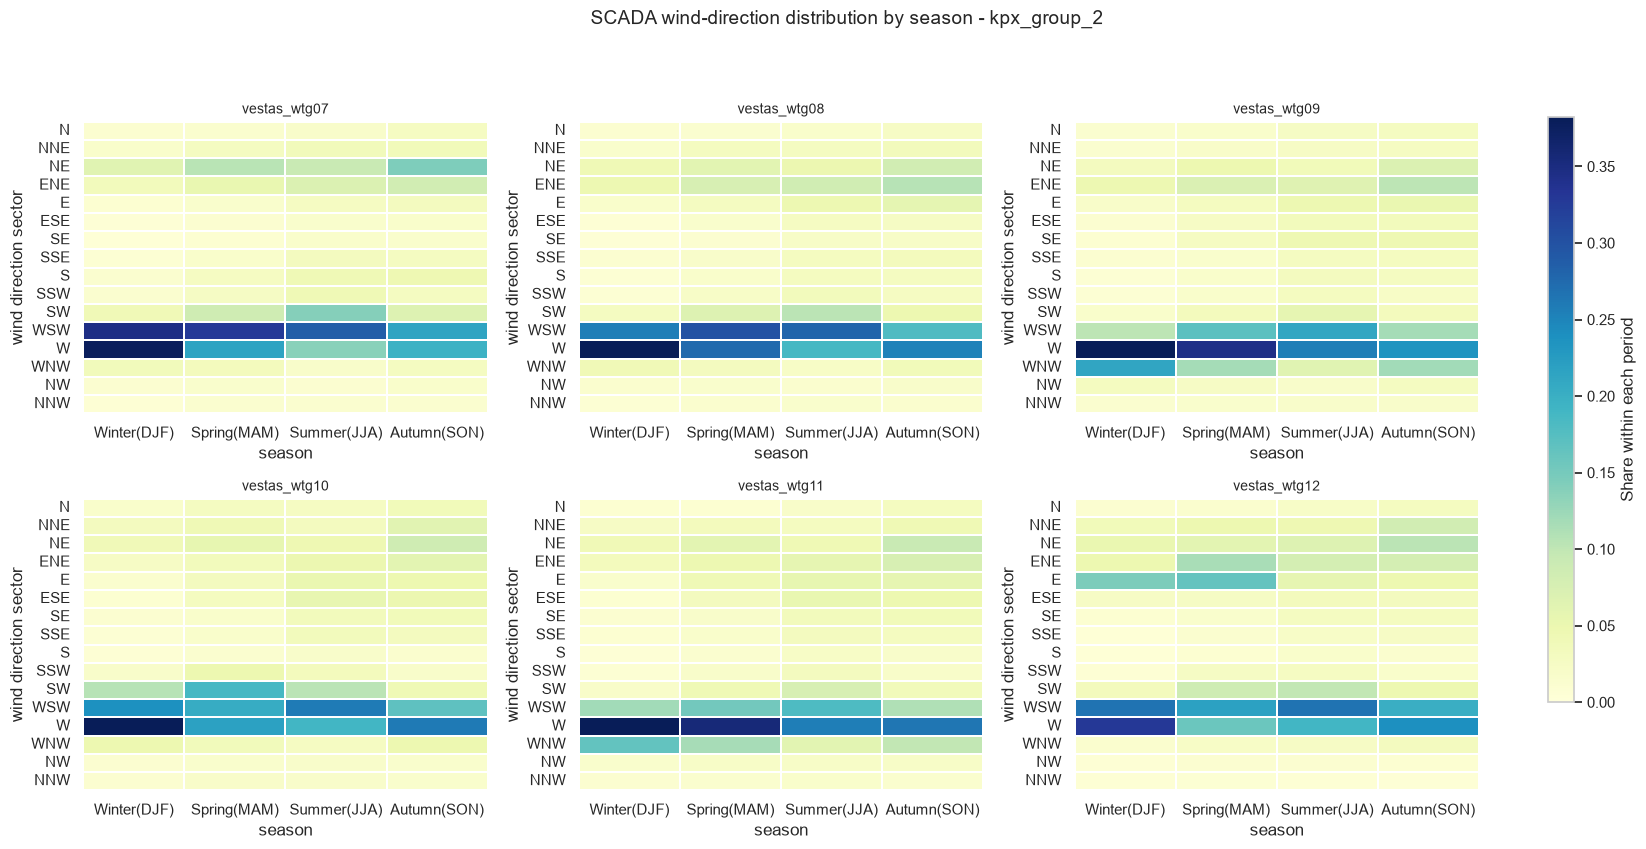

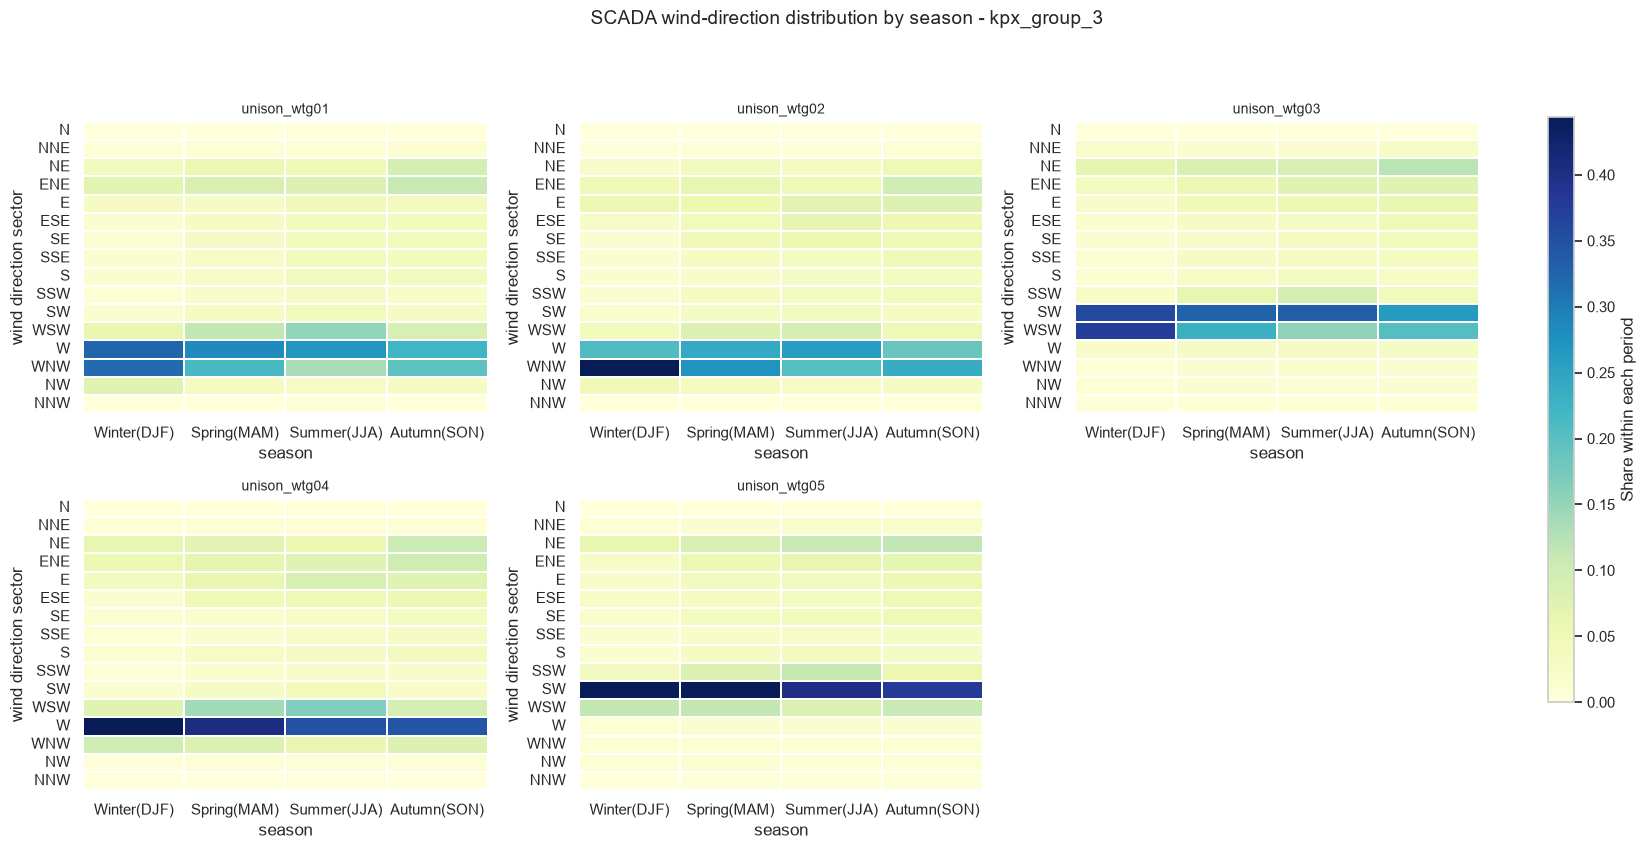

SCADA wind-direction plot files:
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots\scada_wind_direction_hour_sector_heatmap_kpx_group_1.png
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots\scada_wind_direction_hour_sector_heatmap_kpx_group_2.png
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots\scada_wind_direction_hour_sector_heatmap_kpx_group_3.png
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots\scada_wind_direction_month_sector_heatmap_kpx_group_1.png
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots\scada_wind_direction_month_sector_heatmap_kpx_group_2.png
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots\scada_wind_direction_month_sector_heatmap_kpx_group_3.png
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\plots\scada_wind_direction_season_sector_heatmap_kpx_group_1.png
- C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_c

In [13]:

COMPASS_SECTORS_16 = [
    "N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW",
]
COMPASS_SECTOR_WIDTH_DEG = 360 / len(COMPASS_SECTORS_16)
MONTH_ORDER = list(range(1, 13))
SEASON_ORDER = ["Winter(DJF)", "Spring(MAM)", "Summer(JJA)", "Autumn(SON)"]
SEASON_MAP = {
    12: "Winter(DJF)", 1: "Winter(DJF)", 2: "Winter(DJF)",
    3: "Spring(MAM)", 4: "Spring(MAM)", 5: "Spring(MAM)",
    6: "Summer(JJA)", 7: "Summer(JJA)", 8: "Summer(JJA)",
    9: "Autumn(SON)", 10: "Autumn(SON)", 11: "Autumn(SON)",
}


def normalize_direction_deg(direction: pd.Series) -> pd.Series:
    return pd.to_numeric(direction, errors="coerce") % 360


def direction_to_sector(direction_deg: pd.Series) -> pd.Categorical:
    normalized = normalize_direction_deg(direction_deg)
    sector = np.full(len(normalized), np.nan, dtype=object)
    mask = normalized.notna().to_numpy()
    sector_idx = np.floor(
        ((normalized[mask].to_numpy() + COMPASS_SECTOR_WIDTH_DEG / 2) % 360) / COMPASS_SECTOR_WIDTH_DEG
    ).astype(int)
    sector[mask] = np.array(COMPASS_SECTORS_16, dtype=object)[sector_idx]
    return pd.Categorical(sector, categories=COMPASS_SECTORS_16, ordered=True)


def add_wind_direction_time_features(scada_long_df: pd.DataFrame) -> pd.DataFrame:
    out = scada_long_df.copy()
    out["wind_direction_deg"] = normalize_direction_deg(out["wind_direction"])
    out["wind_direction_sector"] = direction_to_sector(out["wind_direction_deg"])
    out["hour"] = out["kst_dtm"].dt.hour
    out["month"] = out["kst_dtm"].dt.month
    out["season"] = pd.Categorical(out["month"].map(SEASON_MAP), categories=SEASON_ORDER, ordered=True)
    out["year_month"] = out["kst_dtm"].dt.to_period("M").astype(str)
    return out


def circular_summary(scada_wd_df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    valid = scada_wd_df.dropna(subset=["wind_direction_deg"]).copy()
    valid["wd_rad"] = np.deg2rad(valid["wind_direction_deg"])
    valid["wd_sin"] = np.sin(valid["wd_rad"])
    valid["wd_cos"] = np.cos(valid["wd_rad"])

    summary = (
        valid
        .groupby(group_cols, observed=True)
        .agg(
            n_obs=("wind_direction_deg", "count"),
            mean_wind_speed=("wind_speed", "mean"),
            median_wind_speed=("wind_speed", "median"),
            mean_sin=("wd_sin", "mean"),
            mean_cos=("wd_cos", "mean"),
        )
        .reset_index()
    )
    summary["circular_mean_direction_deg"] = (
        np.degrees(np.arctan2(summary["mean_sin"], summary["mean_cos"])) + 360
    ) % 360
    summary["resultant_length"] = np.hypot(summary["mean_sin"], summary["mean_cos"])
    summary["circular_std_deg"] = np.where(
        summary["resultant_length"] > 0,
        np.degrees(np.sqrt(-2 * np.log(np.clip(summary["resultant_length"], 1e-12, 1)))),
        np.nan,
    )

    sector_counts = (
        valid
        .groupby(group_cols + ["wind_direction_sector"], observed=True)
        .size()
        .rename("sector_count")
        .reset_index()
        .sort_values(group_cols + ["sector_count", "wind_direction_sector"], ascending=[True] * len(group_cols) + [False, True])
    )
    dominant = sector_counts.drop_duplicates(group_cols).rename(
        columns={"wind_direction_sector": "dominant_sector", "sector_count": "dominant_sector_count"}
    )
    summary = summary.merge(dominant[group_cols + ["dominant_sector", "dominant_sector_count"]], on=group_cols, how="left")
    summary["dominant_sector_share"] = summary["dominant_sector_count"] / summary["n_obs"]

    return summary.drop(columns=["mean_sin", "mean_cos"]).sort_values(group_cols).reset_index(drop=True)


def sector_distribution(scada_wd_df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    valid = scada_wd_df.dropna(subset=["wind_direction_deg"]).copy()
    counts = (
        valid
        .groupby(group_cols + ["wind_direction_sector"], observed=False)
        .size()
        .rename("n_obs")
        .reset_index()
    )
    totals = counts.groupby(group_cols, observed=True)["n_obs"].transform("sum")
    counts["share"] = np.where(totals > 0, counts["n_obs"] / totals, 0)
    return counts.sort_values(group_cols + ["wind_direction_sector"]).reset_index(drop=True)


scada_wd_long = add_wind_direction_time_features(scada_long)

scada_wd_hourly_summary = circular_summary(scada_wd_long, ["group", "source", "turbine_no", "turbine_id", "hour"])
scada_wd_hour_sector_distribution = sector_distribution(scada_wd_long, ["group", "source", "turbine_no", "turbine_id", "hour"])

scada_wd_monthly_summary = circular_summary(scada_wd_long, ["group", "source", "turbine_no", "turbine_id", "month"])
scada_wd_month_sector_distribution = sector_distribution(scada_wd_long, ["group", "source", "turbine_no", "turbine_id", "month"])

scada_wd_seasonal_summary = circular_summary(scada_wd_long, ["group", "source", "turbine_no", "turbine_id", "season"])
scada_wd_season_sector_distribution = sector_distribution(scada_wd_long, ["group", "source", "turbine_no", "turbine_id", "season"])

print("SCADA wind-direction long rows:", scada_wd_long.shape)
print("Rows with valid wind_direction:", scada_wd_long["wind_direction_deg"].notna().sum())
print("Hourly summary:", scada_wd_hourly_summary.shape)
print("Monthly summary:", scada_wd_monthly_summary.shape)
print("Seasonal summary:", scada_wd_seasonal_summary.shape)
display(scada_wd_hourly_summary.head())
display(scada_wd_monthly_summary.head())
display(scada_wd_seasonal_summary.head())


def plot_sector_distribution_heatmaps_by_group(
    distribution_df: pd.DataFrame,
    period_col: str,
    period_order: list,
    title_prefix: str,
    output_prefix: str,
    x_label: str,
) -> list[Path]:
    plot_files = []
    if distribution_df.empty:
        print(f"No rows to plot for {title_prefix}.")
        return plot_files

    for group, group_df in distribution_df.groupby("group", sort=True, observed=True):
        turbines = group_df[["turbine_no", "turbine_id"]].drop_duplicates().sort_values("turbine_no")
        n_cols = 3
        n_rows = math.ceil(len(turbines) / n_cols)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.7 * n_cols, 3.9 * n_rows + 0.8), squeeze=False)
        axes_flat = axes.ravel()
        group_vmax = max(0.05, min(1.0, group_df["share"].quantile(0.99)))

        for ax, row in zip(axes_flat, turbines.itertuples(index=False)):
            turbine_df = group_df[group_df["turbine_id"] == row.turbine_id]
            heat = (
                turbine_df
                .pivot_table(
                    index="wind_direction_sector",
                    columns=period_col,
                    values="share",
                    aggfunc="sum",
                    observed=False,
                    fill_value=0,
                )
                .reindex(index=COMPASS_SECTORS_16, columns=period_order, fill_value=0)
            )
            sns.heatmap(
                heat,
                ax=ax,
                cmap="YlGnBu",
                vmin=0,
                vmax=group_vmax,
                cbar=False,
                linewidths=0.2,
                linecolor="white",
            )
            ax.set_title(row.turbine_id, fontsize=10)
            ax.set_xlabel(x_label)
            ax.set_ylabel("wind direction sector")
            ax.tick_params(axis="x", rotation=0)
            ax.tick_params(axis="y", rotation=0)

        for ax in axes_flat[len(turbines):]:
            ax.axis("off")

        fig.suptitle(f"{title_prefix} - {group}", y=0.985, fontsize=14)
        fig.tight_layout(rect=[0, 0, 0.88, 0.94])
        mappable = axes_flat[0].collections[0]
        cbar_ax = fig.add_axes([0.91, 0.18, 0.015, 0.68])
        cbar = fig.colorbar(mappable, cax=cbar_ax)
        cbar.set_label("Share within each period")

        out_path = PLOT_DIR / f"{output_prefix}_{group}.png"
        fig.savefig(out_path, dpi=160, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        plot_files.append(out_path)

    return plot_files


scada_wd_plot_files = []
scada_wd_plot_files += plot_sector_distribution_heatmaps_by_group(
    scada_wd_hour_sector_distribution,
    period_col="hour",
    period_order=list(range(24)),
    title_prefix="SCADA wind-direction distribution by hour",
    output_prefix="scada_wind_direction_hour_sector_heatmap",
    x_label="hour of day",
)
scada_wd_plot_files += plot_sector_distribution_heatmaps_by_group(
    scada_wd_month_sector_distribution,
    period_col="month",
    period_order=MONTH_ORDER,
    title_prefix="SCADA wind-direction distribution by month",
    output_prefix="scada_wind_direction_month_sector_heatmap",
    x_label="month",
)
scada_wd_plot_files += plot_sector_distribution_heatmaps_by_group(
    scada_wd_season_sector_distribution,
    period_col="season",
    period_order=SEASON_ORDER,
    title_prefix="SCADA wind-direction distribution by season",
    output_prefix="scada_wind_direction_season_sector_heatmap",
    x_label="season",
)

print("SCADA wind-direction plot files:")
for path in scada_wd_plot_files:
    print("-", path)


### 9.2 Link SCADA Wind-Direction Results to LDAPS Grid IDs


In [14]:

def parse_nearest_grid_id(value: object) -> float:
    match = re.search(r"(\d+)", str(value))
    return int(match.group(1)) if match else np.nan


def parse_nearest_grid_distance_km(value: object) -> float:
    match = re.search(r"\(([0-9.]+)\s*km\)", str(value))
    return float(match.group(1)) if match else np.nan


def load_turbine_ldaps_map(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing turbine-to-weather-grid mapping file: {path}")

    mapping = pd.read_csv(path)
    mapping["source"] = mapping["maker"].str.lower().map({"vestas": "vestas", "unison": "unison"})
    mapping["turbine_no"] = mapping["turbine_no"].astype(int)
    mapping["turbine_id"] = mapping["source"] + "_wtg" + mapping["turbine_no"].astype(str).str.zfill(2)
    mapping["group"] = pd.Series(pd.NA, index=mapping.index, dtype="string")
    mapping.loc[(mapping["source"] == "vestas") & mapping["turbine_no"].between(1, 6), "group"] = "kpx_group_1"
    mapping.loc[(mapping["source"] == "vestas") & mapping["turbine_no"].between(7, 12), "group"] = "kpx_group_2"
    mapping.loc[mapping["source"] == "unison", "group"] = "kpx_group_3"
    mapping["nearest_ldaps_grid_id"] = mapping["nearest_ldaps"].apply(parse_nearest_grid_id).astype("Int64")
    mapping["nearest_ldaps_distance_km"] = mapping["nearest_ldaps"].apply(parse_nearest_grid_distance_km)
    return mapping[
        [
            "group", "source", "turbine_no", "turbine_id", "site", "lat", "lon",
            "nearest_ldaps_grid_id", "nearest_ldaps_distance_km", "nearest_ldaps", "top4_ldaps",
        ]
    ].sort_values(["group", "turbine_no"]).reset_index(drop=True)


turbine_ldaps_map = load_turbine_ldaps_map(TURBINE_GRID_PATH)
join_keys = ["group", "source", "turbine_no", "turbine_id"]
map_cols = join_keys + ["site", "lat", "lon", "nearest_ldaps_grid_id", "nearest_ldaps_distance_km", "nearest_ldaps", "top4_ldaps"]

scada_wd_hourly_summary_ldaps = scada_wd_hourly_summary.merge(turbine_ldaps_map[map_cols], on=join_keys, how="left", validate="many_to_one")
scada_wd_monthly_summary_ldaps = scada_wd_monthly_summary.merge(turbine_ldaps_map[map_cols], on=join_keys, how="left", validate="many_to_one")
scada_wd_seasonal_summary_ldaps = scada_wd_seasonal_summary.merge(turbine_ldaps_map[map_cols], on=join_keys, how="left", validate="many_to_one")

scada_wd_hour_sector_distribution_ldaps = scada_wd_hour_sector_distribution.merge(turbine_ldaps_map[map_cols], on=join_keys, how="left", validate="many_to_one")
scada_wd_month_sector_distribution_ldaps = scada_wd_month_sector_distribution.merge(turbine_ldaps_map[map_cols], on=join_keys, how="left", validate="many_to_one")
scada_wd_season_sector_distribution_ldaps = scada_wd_season_sector_distribution.merge(turbine_ldaps_map[map_cols], on=join_keys, how="left", validate="many_to_one")

scada_wd_long_ldaps = scada_wd_long.merge(turbine_ldaps_map[map_cols], on=join_keys, how="left", validate="many_to_one")
scada_wd_ldaps_grid_hourly_summary = circular_summary(scada_wd_long_ldaps, ["nearest_ldaps_grid_id", "hour"])
scada_wd_ldaps_grid_monthly_summary = circular_summary(scada_wd_long_ldaps, ["nearest_ldaps_grid_id", "month"])
scada_wd_ldaps_grid_seasonal_summary = circular_summary(scada_wd_long_ldaps, ["nearest_ldaps_grid_id", "season"])

# Attach the list of turbines represented by each LDAPS grid summary row.
grid_turbines = (
    turbine_ldaps_map
    .groupby("nearest_ldaps_grid_id", observed=True)
    .agg(
        n_turbines=("turbine_id", "nunique"),
        turbine_ids=("turbine_id", lambda s: ", ".join(sorted(s))),
        groups=("group", lambda s: ", ".join(sorted(s.unique()))),
    )
    .reset_index()
)
for name in [
    "scada_wd_ldaps_grid_hourly_summary",
    "scada_wd_ldaps_grid_monthly_summary",
    "scada_wd_ldaps_grid_seasonal_summary",
]:
    globals()[name] = globals()[name].merge(grid_turbines, on="nearest_ldaps_grid_id", how="left", validate="many_to_one")

# Save linked turbine-level summaries and LDAPS-grid-level summaries.
turbine_ldaps_map.to_csv(OUTPUT_PATHS["scada_wd_turbine_ldaps_map"], index=False, encoding="utf-8-sig")
scada_wd_hourly_summary_ldaps.to_csv(OUTPUT_PATHS["scada_wd_hourly_summary"], index=False, encoding="utf-8-sig")
scada_wd_hour_sector_distribution_ldaps.to_csv(OUTPUT_PATHS["scada_wd_hour_sector_distribution"], index=False, encoding="utf-8-sig")
scada_wd_monthly_summary_ldaps.to_csv(OUTPUT_PATHS["scada_wd_monthly_summary"], index=False, encoding="utf-8-sig")
scada_wd_month_sector_distribution_ldaps.to_csv(OUTPUT_PATHS["scada_wd_month_sector_distribution"], index=False, encoding="utf-8-sig")
scada_wd_seasonal_summary_ldaps.to_csv(OUTPUT_PATHS["scada_wd_seasonal_summary"], index=False, encoding="utf-8-sig")
scada_wd_season_sector_distribution_ldaps.to_csv(OUTPUT_PATHS["scada_wd_season_sector_distribution"], index=False, encoding="utf-8-sig")
scada_wd_ldaps_grid_hourly_summary.to_csv(OUTPUT_PATHS["scada_wd_ldaps_grid_hourly_summary"], index=False, encoding="utf-8-sig")
scada_wd_ldaps_grid_monthly_summary.to_csv(OUTPUT_PATHS["scada_wd_ldaps_grid_monthly_summary"], index=False, encoding="utf-8-sig")
scada_wd_ldaps_grid_seasonal_summary.to_csv(OUTPUT_PATHS["scada_wd_ldaps_grid_seasonal_summary"], index=False, encoding="utf-8-sig")

print("Turbine-LDAPS map:", turbine_ldaps_map.shape)
display(turbine_ldaps_map)
print("Hourly turbine summary linked to LDAPS:", scada_wd_hourly_summary_ldaps.shape)
print("Monthly turbine summary linked to LDAPS:", scada_wd_monthly_summary_ldaps.shape)
print("Seasonal turbine summary linked to LDAPS:", scada_wd_seasonal_summary_ldaps.shape)
print("LDAPS-grid hourly summary:", scada_wd_ldaps_grid_hourly_summary.shape)
print("LDAPS-grid monthly summary:", scada_wd_ldaps_grid_monthly_summary.shape)
print("LDAPS-grid seasonal summary:", scada_wd_ldaps_grid_seasonal_summary.shape)
display(scada_wd_ldaps_grid_hourly_summary.head(20))
display(scada_wd_ldaps_grid_monthly_summary.head(20))
display(scada_wd_ldaps_grid_seasonal_summary.head(20))

print("Saved SCADA wind-direction LDAPS-linked files:")
for key in [
    "scada_wd_turbine_ldaps_map",
    "scada_wd_hourly_summary",
    "scada_wd_hour_sector_distribution",
    "scada_wd_monthly_summary",
    "scada_wd_month_sector_distribution",
    "scada_wd_seasonal_summary",
    "scada_wd_season_sector_distribution",
    "scada_wd_ldaps_grid_hourly_summary",
    "scada_wd_ldaps_grid_monthly_summary",
    "scada_wd_ldaps_grid_seasonal_summary",
]:
    print(f"- {key}: {OUTPUT_PATHS[key]}")


Turbine-LDAPS map: (17, 11)


,group,source,turbine_no,turbine_id,site,lat,lon,nearest_ldaps_grid_id,nearest_ldaps_distance_km,nearest_ldaps,top4_ldaps
0,kpx_group_1,vestas,1,vestas_wtg01,Taebaek-Gadeoksan,37.282114,128.950583,10,1.00,10 (1.00 km),"10(1.00), 5(1.01), 11(1.17), 6(1.18)"
1,kpx_group_1,vestas,2,vestas_wtg02,Taebaek-Gadeoksan,37.284458,128.949542,5,0.75,5 (0.75 km),"5(0.75), 6(1.12), 10(1.15), 11(1.42)"
2,kpx_group_1,vestas,3,vestas_wtg03,Taebaek-Gadeoksan,37.286525,128.949719,5,0.62,5 (0.62 km),"5(0.62), 6(1.03), 10(1.36), 11(1.59)"
3,kpx_group_1,vestas,4,vestas_wtg04,Taebaek-Gadeoksan,37.289753,128.951022,5,0.65,5 (0.65 km),"5(0.65), 6(0.89), 1(1.61), 2(1.72)"
4,kpx_group_1,vestas,5,vestas_wtg05,Taebaek-Gadeoksan,37.291167,128.954328,6,0.65,6 (0.65 km),"6(0.65), 5(0.96), 2(1.44), 1(1.61)"
5,kpx_group_1,vestas,6,vestas_wtg06,Taebaek-Gadeoksan,37.288744,128.956933,6,0.36,6 (0.36 km),"6(0.36), 5(1.17), 11(1.56), 2(1.61)"
6,kpx_group_2,vestas,7,vestas_wtg07,Taebaek-Gadeoksan,37.287833,128.959631,6,0.16,6 (0.16 km),"6(0.16), 5(1.42), 11(1.43), 7(1.66)"
7,kpx_group_2,vestas,8,vestas_wtg08,Taebaek-Gadeoksan,37.286469,128.963122,6,0.32,6 (0.32 km),"6(0.32), 11(1.30), 7(1.37), 5(1.75)"
8,kpx_group_2,vestas,9,vestas_wtg09,Taebaek-Gadeoksan,37.283603,128.965956,6,0.73,6 (0.73 km),"6(0.73), 11(1.08), 7(1.22), 12(1.46)"
9,kpx_group_2,vestas,10,vestas_wtg10,Taebaek-Gadeoksan,37.281325,128.967828,11,0.96,11 (0.96 km),"11(0.96), 6(1.03), 12(1.16), 7(1.22)"


Hourly turbine summary linked to LDAPS: (408, 21)
Monthly turbine summary linked to LDAPS: (204, 21)
Seasonal turbine summary linked to LDAPS: (68, 21)
LDAPS-grid hourly summary: (120, 14)
LDAPS-grid monthly summary: (60, 14)
LDAPS-grid seasonal summary: (20, 14)


,nearest_ldaps_grid_id,hour,n_obs,mean_wind_speed,median_wind_speed,circular_mean_direction_deg,resultant_length,circular_std_deg,dominant_sector,dominant_sector_count,dominant_sector_share,n_turbines,turbine_ids,groups
0,5,0,19713,7.745154,7.3950,271.563667,0.546850,62.951379,W,6207,0.314868,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
1,5,1,19728,7.752637,7.4940,273.704578,0.543550,63.266249,W,6206,0.314578,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
2,5,2,19728,7.787384,7.5390,276.293015,0.531395,64.429060,W,6140,0.311233,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
3,5,3,19728,7.780092,7.5200,278.600826,0.518881,65.632057,W,5983,0.303275,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
4,5,4,19728,7.762036,7.4340,280.858860,0.504425,67.030473,W,5848,0.296431,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
5,5,5,19728,7.652747,7.2380,283.239766,0.475504,69.862358,W,5620,0.284874,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
6,5,6,19728,7.549843,7.1020,286.139988,0.439911,73.427333,W,5420,0.274736,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
7,5,7,19728,7.295758,6.8000,285.777250,0.407923,76.728294,W,5257,0.266474,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
8,5,8,19728,6.904495,6.3000,284.280473,0.376048,80.133791,W,5316,0.269465,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
9,5,9,19728,6.499670,5.7380,279.738415,0.364487,81.402914,W,5580,0.282847,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1


,nearest_ldaps_grid_id,month,n_obs,mean_wind_speed,median_wind_speed,circular_mean_direction_deg,resultant_length,circular_std_deg,dominant_sector,dominant_sector_count,dominant_sector_share,n_turbines,turbine_ids,groups
0,5,1,40161,8.724487,8.600,277.747187,0.745742,43.888429,W,17498,0.435696,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
1,5,2,36720,7.631946,7.008,278.965740,0.476243,69.789292,W,12391,0.337446,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
2,5,3,40176,7.643154,7.117,272.656178,0.577263,60.062653,W,14255,0.354814,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
3,5,4,38880,7.178695,6.531,273.059711,0.348792,83.159022,W,12096,0.311111,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
4,5,5,40176,7.150104,6.750,272.875764,0.510616,66.430330,W,13432,0.334329,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
5,5,6,38880,6.080756,5.566,266.084409,0.398093,77.764915,W,10774,0.277109,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
6,5,7,40176,6.535975,5.600,254.794246,0.478357,69.580686,W,10369,0.258089,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
7,5,8,40176,5.349580,4.582,268.489878,0.190364,104.360733,W,8151,0.202882,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
8,5,9,38880,4.898884,4.555,56.016574,0.089009,126.025198,ENE,6446,0.165792,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
9,5,10,40176,5.701048,5.027,293.536902,0.222138,99.386534,W,9546,0.237605,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1


,nearest_ldaps_grid_id,season,n_obs,mean_wind_speed,median_wind_speed,circular_mean_direction_deg,resultant_length,circular_std_deg,dominant_sector,dominant_sector_count,dominant_sector_share,n_turbines,turbine_ids,groups
0,5,Winter(DJF),117057,8.754929,8.594,277.626991,0.678885,50.427047,W,49329,0.421410,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
1,5,Spring(MAM),119232,7.325564,6.824,272.830395,0.480303,69.388880,W,39783,0.333660,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
2,5,Summer(JJA),119232,5.987771,5.200,261.396153,0.353149,82.667559,W,29294,0.245689,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
3,5,Autumn(SON),117936,6.148637,5.281,280.365046,0.237699,97.124416,W,29538,0.250458,3,"vestas_wtg02, vestas_wtg03, vestas_wtg04",kpx_group_1
4,6,Winter(DJF),221158,7.762361,7.574,272.954914,0.643906,53.760547,W,93622,0.423326,6,"unison_wtg01, vestas_wtg05, vestas_wtg06, vest...","kpx_group_1, kpx_group_2, kpx_group_3"
5,6,Spring(MAM),225099,6.540188,5.980,266.800352,0.447767,72.631639,W,64457,0.286350,6,"unison_wtg01, vestas_wtg05, vestas_wtg06, vest...","kpx_group_1, kpx_group_2, kpx_group_3"
6,6,Summer(JJA),225132,5.575494,4.800,249.192092,0.368544,80.955303,WSW,50970,0.226401,6,"unison_wtg01, vestas_wtg05, vestas_wtg06, vest...","kpx_group_1, kpx_group_2, kpx_group_3"
7,6,Autumn(SON),222762,5.709352,4.910,271.231318,0.234450,97.588461,W,52118,0.233963,6,"unison_wtg01, vestas_wtg05, vestas_wtg06, vest...","kpx_group_1, kpx_group_2, kpx_group_3"
8,10,Winter(DJF),39019,8.827022,8.848,279.702949,0.627343,55.328927,W,12524,0.320972,1,vestas_wtg01,kpx_group_1
9,10,Spring(MAM),39744,7.244093,6.813,281.781748,0.431876,74.246890,W,7911,0.199049,1,vestas_wtg01,kpx_group_1


Saved SCADA wind-direction LDAPS-linked files:
- scada_wd_turbine_ldaps_map: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_wind_direction_turbine_ldaps_map.csv
- scada_wd_hourly_summary: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_wind_direction_hourly_summary_with_ldaps.csv
- scada_wd_hour_sector_distribution: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_wind_direction_hour_sector_distribution_with_ldaps.csv
- scada_wd_monthly_summary: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_wind_direction_monthly_summary_with_ldaps.csv
- scada_wd_month_sector_distribution: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_wind_direction_month_sector_distribution_with_ldaps.csv
- scada_wd_seasonal_summary: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_wind_direction_seasonal_summary_with_ldaps.csv
- scada_wd_season_sector_distribution: C:\Users\심현석\Docume

### 9.3 Month-Hour and Season-Hour Wind-Direction Details


In [15]:

MONTH_LABELS = {i: f"{i:02d}" for i in MONTH_ORDER}
SEASON_LABELS = {season: season.replace("(", "\n(") for season in SEASON_ORDER}
HOUR_ORDER = list(range(24))


def plot_period_hour_sector_heatmaps_by_turbine(
    distribution_df: pd.DataFrame,
    period_col: str,
    period_order: list,
    period_label_map: dict,
    title_prefix: str,
    output_prefix: str,
    n_cols: int,
) -> list[Path]:
    plot_files = []
    if distribution_df.empty:
        print(f"No rows to plot for {title_prefix}.")
        return plot_files

    turbines = distribution_df[["group", "turbine_no", "turbine_id"]].drop_duplicates().sort_values(["group", "turbine_no"])
    global_vmax = max(0.05, min(1.0, distribution_df["share"].quantile(0.995)))

    for row in turbines.itertuples(index=False):
        turbine_df = distribution_df[distribution_df["turbine_id"] == row.turbine_id]
        n_rows = math.ceil(len(period_order) / n_cols)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 3.2 * n_rows + 0.7), squeeze=False)
        axes_flat = axes.ravel()

        for ax, period_value in zip(axes_flat, period_order):
            period_df = turbine_df[turbine_df[period_col] == period_value]
            heat = (
                period_df
                .pivot_table(
                    index="wind_direction_sector",
                    columns="hour",
                    values="share",
                    aggfunc="sum",
                    observed=False,
                    fill_value=0,
                )
                .reindex(index=COMPASS_SECTORS_16, columns=HOUR_ORDER, fill_value=0)
            )
            sns.heatmap(
                heat,
                ax=ax,
                cmap="YlGnBu",
                vmin=0,
                vmax=global_vmax,
                cbar=False,
                linewidths=0.15,
                linecolor="white",
            )
            ax.set_title(str(period_label_map.get(period_value, period_value)), fontsize=9)
            ax.set_xlabel("hour")
            ax.set_ylabel("wind direction sector")
            ax.tick_params(axis="x", rotation=0, labelsize=7)
            ax.tick_params(axis="y", rotation=0, labelsize=7)

        for ax in axes_flat[len(period_order):]:
            ax.axis("off")

        fig.suptitle(f"{title_prefix} - {row.turbine_id} ({row.group})", y=0.985, fontsize=13)
        fig.tight_layout(rect=[0, 0, 0.90, 0.94])
        mappable = axes_flat[0].collections[0]
        cbar_ax = fig.add_axes([0.925, 0.18, 0.015, 0.68])
        cbar = fig.colorbar(mappable, cax=cbar_ax)
        cbar.set_label("Share within each period-hour")

        out_path = PLOT_DIR / f"{output_prefix}_{row.turbine_id}.png"
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        plot_files.append(out_path)

    return plot_files


def plot_period_hour_sector_polar_by_turbine(
    distribution_df: pd.DataFrame,
    period_col: str,
    period_order: list,
    period_label_map: dict,
    title_prefix: str,
    output_prefix: str,
    n_cols: int,
) -> list[Path]:
    plot_files = []
    if distribution_df.empty:
        print(f"No rows to plot for {title_prefix}.")
        return plot_files

    turbines = distribution_df[["group", "turbine_no", "turbine_id"]].drop_duplicates().sort_values(["group", "turbine_no"])
    global_vmax = max(0.05, min(1.0, distribution_df["share"].quantile(0.995)))
    theta_edges = np.deg2rad(np.linspace(-COMPASS_SECTOR_WIDTH_DEG / 2, 360 - COMPASS_SECTOR_WIDTH_DEG / 2, len(COMPASS_SECTORS_16) + 1))
    hour_edges = np.arange(25)

    for row in turbines.itertuples(index=False):
        turbine_df = distribution_df[distribution_df["turbine_id"] == row.turbine_id]
        n_rows = math.ceil(len(period_order) / n_cols)
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(3.8 * n_cols, 3.8 * n_rows + 0.9),
            subplot_kw={"projection": "polar"},
            squeeze=False,
        )
        axes_flat = axes.ravel()
        mappable = None

        for ax, period_value in zip(axes_flat, period_order):
            period_df = turbine_df[turbine_df[period_col] == period_value]
            heat = (
                period_df
                .pivot_table(
                    index="hour",
                    columns="wind_direction_sector",
                    values="share",
                    aggfunc="sum",
                    observed=False,
                    fill_value=0,
                )
                .reindex(index=HOUR_ORDER, columns=COMPASS_SECTORS_16, fill_value=0)
            )
            mappable = ax.pcolormesh(theta_edges, hour_edges, heat.to_numpy(), cmap="YlGnBu", vmin=0, vmax=global_vmax, shading="flat")
            ax.set_theta_zero_location("N")
            ax.set_theta_direction(-1)
            ax.set_thetagrids([0, 90, 180, 270], ["N", "E", "S", "W"], fontsize=8)
            ax.set_ylim(0, 24)
            ax.set_yticks([0, 6, 12, 18, 24])
            ax.set_yticklabels(["0", "6", "12", "18", "24"], fontsize=7)
            ax.set_rlabel_position(135)
            ax.grid(color="white", linewidth=0.4)
            ax.set_title(str(period_label_map.get(period_value, period_value)), fontsize=9, pad=10)

        for ax in axes_flat[len(period_order):]:
            ax.axis("off")

        fig.suptitle(f"{title_prefix} - {row.turbine_id} ({row.group})", y=0.985, fontsize=13)
        fig.tight_layout(rect=[0, 0, 0.90, 0.94])
        if mappable is not None:
            cbar_ax = fig.add_axes([0.925, 0.18, 0.015, 0.68])
            cbar = fig.colorbar(mappable, cax=cbar_ax)
            cbar.set_label("Share within each period-hour")

        out_path = PLOT_DIR / f"{output_prefix}_{row.turbine_id}.png"
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        plot_files.append(out_path)

    return plot_files


scada_wd_month_hourly_summary = circular_summary(scada_wd_long, ["group", "source", "turbine_no", "turbine_id", "month", "hour"])
scada_wd_month_hour_sector_distribution = sector_distribution(scada_wd_long, ["group", "source", "turbine_no", "turbine_id", "month", "hour"])

scada_wd_season_hourly_summary = circular_summary(scada_wd_long, ["group", "source", "turbine_no", "turbine_id", "season", "hour"])
scada_wd_season_hour_sector_distribution = sector_distribution(scada_wd_long, ["group", "source", "turbine_no", "turbine_id", "season", "hour"])

scada_wd_month_hourly_summary_ldaps = scada_wd_month_hourly_summary.merge(turbine_ldaps_map[map_cols], on=join_keys, how="left", validate="many_to_one")
scada_wd_month_hour_sector_distribution_ldaps = scada_wd_month_hour_sector_distribution.merge(turbine_ldaps_map[map_cols], on=join_keys, how="left", validate="many_to_one")
scada_wd_season_hourly_summary_ldaps = scada_wd_season_hourly_summary.merge(turbine_ldaps_map[map_cols], on=join_keys, how="left", validate="many_to_one")
scada_wd_season_hour_sector_distribution_ldaps = scada_wd_season_hour_sector_distribution.merge(turbine_ldaps_map[map_cols], on=join_keys, how="left", validate="many_to_one")

scada_wd_ldaps_grid_month_hourly_summary = circular_summary(scada_wd_long_ldaps, ["nearest_ldaps_grid_id", "month", "hour"])
scada_wd_ldaps_grid_season_hourly_summary = circular_summary(scada_wd_long_ldaps, ["nearest_ldaps_grid_id", "season", "hour"])
scada_wd_ldaps_grid_month_hourly_summary = scada_wd_ldaps_grid_month_hourly_summary.merge(grid_turbines, on="nearest_ldaps_grid_id", how="left", validate="many_to_one")
scada_wd_ldaps_grid_season_hourly_summary = scada_wd_ldaps_grid_season_hourly_summary.merge(grid_turbines, on="nearest_ldaps_grid_id", how="left", validate="many_to_one")

scada_wd_month_hourly_summary_ldaps.to_csv(OUTPUT_PATHS["scada_wd_month_hourly_summary"], index=False, encoding="utf-8-sig")
scada_wd_month_hour_sector_distribution_ldaps.to_csv(OUTPUT_PATHS["scada_wd_month_hour_sector_distribution"], index=False, encoding="utf-8-sig")
scada_wd_season_hourly_summary_ldaps.to_csv(OUTPUT_PATHS["scada_wd_season_hourly_summary"], index=False, encoding="utf-8-sig")
scada_wd_season_hour_sector_distribution_ldaps.to_csv(OUTPUT_PATHS["scada_wd_season_hour_sector_distribution"], index=False, encoding="utf-8-sig")
scada_wd_ldaps_grid_month_hourly_summary.to_csv(OUTPUT_PATHS["scada_wd_ldaps_grid_month_hourly_summary"], index=False, encoding="utf-8-sig")
scada_wd_ldaps_grid_season_hourly_summary.to_csv(OUTPUT_PATHS["scada_wd_ldaps_grid_season_hourly_summary"], index=False, encoding="utf-8-sig")

scada_wd_detail_plot_files = []
scada_wd_detail_plot_files += plot_period_hour_sector_heatmaps_by_turbine(
    scada_wd_month_hour_sector_distribution,
    period_col="month",
    period_order=MONTH_ORDER,
    period_label_map=MONTH_LABELS,
    title_prefix="SCADA wind-direction distribution by month and hour",
    output_prefix="scada_wind_direction_month_hour_sector_heatmap",
    n_cols=4,
)
scada_wd_detail_plot_files += plot_period_hour_sector_heatmaps_by_turbine(
    scada_wd_season_hour_sector_distribution,
    period_col="season",
    period_order=SEASON_ORDER,
    period_label_map=SEASON_LABELS,
    title_prefix="SCADA wind-direction distribution by season and hour",
    output_prefix="scada_wind_direction_season_hour_sector_heatmap",
    n_cols=2,
)
scada_wd_detail_plot_files += plot_period_hour_sector_polar_by_turbine(
    scada_wd_month_hour_sector_distribution,
    period_col="month",
    period_order=MONTH_ORDER,
    period_label_map=MONTH_LABELS,
    title_prefix="Circular SCADA wind-direction distribution by month and hour",
    output_prefix="scada_wind_direction_month_hour_sector_polar",
    n_cols=4,
)
scada_wd_detail_plot_files += plot_period_hour_sector_polar_by_turbine(
    scada_wd_season_hour_sector_distribution,
    period_col="season",
    period_order=SEASON_ORDER,
    period_label_map=SEASON_LABELS,
    title_prefix="Circular SCADA wind-direction distribution by season and hour",
    output_prefix="scada_wind_direction_season_hour_sector_polar",
    n_cols=2,
)

print("Month-hour turbine summary:", scada_wd_month_hourly_summary_ldaps.shape)
print("Month-hour sector distribution:", scada_wd_month_hour_sector_distribution_ldaps.shape)
print("Season-hour turbine summary:", scada_wd_season_hourly_summary_ldaps.shape)
print("Season-hour sector distribution:", scada_wd_season_hour_sector_distribution_ldaps.shape)
print("LDAPS-grid month-hour summary:", scada_wd_ldaps_grid_month_hourly_summary.shape)
print("LDAPS-grid season-hour summary:", scada_wd_ldaps_grid_season_hourly_summary.shape)
display(scada_wd_month_hourly_summary_ldaps.head())
display(scada_wd_season_hourly_summary_ldaps.head())

print("Saved detailed SCADA wind-direction files:")
for key in [
    "scada_wd_month_hourly_summary",
    "scada_wd_month_hour_sector_distribution",
    "scada_wd_season_hourly_summary",
    "scada_wd_season_hour_sector_distribution",
    "scada_wd_ldaps_grid_month_hourly_summary",
    "scada_wd_ldaps_grid_season_hourly_summary",
]:
    print(f"- {key}: {OUTPUT_PATHS[key]}")

print("Detailed SCADA wind-direction plot files:")
for path in scada_wd_detail_plot_files:
    print("-", path)


Month-hour turbine summary: (4896, 22)
Month-hour sector distribution: (78336, 16)
Season-hour turbine summary: (1632, 22)
Season-hour sector distribution: (26112, 16)
LDAPS-grid month-hour summary: (1440, 15)
LDAPS-grid season-hour summary: (480, 15)


,group,source,turbine_no,turbine_id,month,hour,n_obs,mean_wind_speed,median_wind_speed,circular_mean_direction_deg,resultant_length,circular_std_deg,dominant_sector,dominant_sector_count,dominant_sector_share,site,lat,lon,nearest_ldaps_grid_id,nearest_ldaps_distance_km,nearest_ldaps,top4_ldaps
0,kpx_group_1,vestas,1,vestas_wtg01,1,0,553,9.297387,9.465,278.447301,0.737823,44.679784,W,210,0.379747,Taebaek-Gadeoksan,37.282114,128.950583,10,1.0,10 (1.00 km),"10(1.00), 5(1.01), 11(1.17), 6(1.18)"
1,kpx_group_1,vestas,1,vestas_wtg01,1,1,558,9.429289,9.375,280.672462,0.733987,45.061143,W,206,0.369176,Taebaek-Gadeoksan,37.282114,128.950583,10,1.0,10 (1.00 km),"10(1.00), 5(1.01), 11(1.17), 6(1.18)"
2,kpx_group_1,vestas,1,vestas_wtg01,1,2,558,9.396088,9.591,282.248918,0.712590,47.167287,W,197,0.353047,Taebaek-Gadeoksan,37.282114,128.950583,10,1.0,10 (1.00 km),"10(1.00), 5(1.01), 11(1.17), 6(1.18)"
3,kpx_group_1,vestas,1,vestas_wtg01,1,3,558,9.585161,10.180,285.217265,0.716403,46.794366,W,190,0.340502,Taebaek-Gadeoksan,37.282114,128.950583,10,1.0,10 (1.00 km),"10(1.00), 5(1.01), 11(1.17), 6(1.18)"
4,kpx_group_1,vestas,1,vestas_wtg01,1,4,558,9.791306,10.126,286.447517,0.729779,45.478072,W,193,0.345878,Taebaek-Gadeoksan,37.282114,128.950583,10,1.0,10 (1.00 km),"10(1.00), 5(1.01), 11(1.17), 6(1.18)"


,group,source,turbine_no,turbine_id,season,hour,n_obs,mean_wind_speed,median_wind_speed,circular_mean_direction_deg,resultant_length,circular_std_deg,dominant_sector,dominant_sector_count,dominant_sector_share,site,lat,lon,nearest_ldaps_grid_id,nearest_ldaps_distance_km,nearest_ldaps,top4_ldaps
0,kpx_group_1,vestas,1,vestas_wtg01,Winter(DJF),0,1621,9.504195,9.7660,276.951243,0.667102,51.554217,W,549,0.338680,Taebaek-Gadeoksan,37.282114,128.950583,10,1.0,10 (1.00 km),"10(1.00), 5(1.01), 11(1.17), 6(1.18)"
1,kpx_group_1,vestas,1,vestas_wtg01,Winter(DJF),1,1626,9.451207,9.5980,278.523799,0.666468,51.614803,W,560,0.344403,Taebaek-Gadeoksan,37.282114,128.950583,10,1.0,10 (1.00 km),"10(1.00), 5(1.01), 11(1.17), 6(1.18)"
2,kpx_group_1,vestas,1,vestas_wtg01,Winter(DJF),2,1626,9.487859,9.7500,280.271270,0.658794,52.346156,W,561,0.345018,Taebaek-Gadeoksan,37.282114,128.950583,10,1.0,10 (1.00 km),"10(1.00), 5(1.01), 11(1.17), 6(1.18)"
3,kpx_group_1,vestas,1,vestas_wtg01,Winter(DJF),3,1626,9.584637,10.0275,282.240014,0.670776,51.203320,W,557,0.342558,Taebaek-Gadeoksan,37.282114,128.950583,10,1.0,10 (1.00 km),"10(1.00), 5(1.01), 11(1.17), 6(1.18)"
4,kpx_group_1,vestas,1,vestas_wtg01,Winter(DJF),4,1626,9.641842,9.8670,283.433736,0.664940,51.760499,W,547,0.336408,Taebaek-Gadeoksan,37.282114,128.950583,10,1.0,10 (1.00 km),"10(1.00), 5(1.01), 11(1.17), 6(1.18)"


Saved detailed SCADA wind-direction files:
- scada_wd_month_hourly_summary: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_wind_direction_month_hourly_summary_with_ldaps.csv
- scada_wd_month_hour_sector_distribution: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_wind_direction_month_hour_sector_distribution_with_ldaps.csv
- scada_wd_season_hourly_summary: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_wind_direction_season_hourly_summary_with_ldaps.csv
- scada_wd_season_hour_sector_distribution: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_wind_direction_season_hour_sector_distribution_with_ldaps.csv
- scada_wd_ldaps_grid_month_hourly_summary: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_wind_direction_ldaps_grid_month_hourly_summary.csv
- scada_wd_ldaps_grid_season_hourly_summary: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\scada_wind_direction_ld

## 10. Compact Summary Tables


In [16]:

summary_missing = missing_label_times.groupby("group").agg(
    n_missing=("missing_kst_dtm", "count"),
    first_missing=("missing_kst_dtm", "min"),
    last_missing=("missing_kst_dtm", "max"),
).reset_index()

summary_scada = missing_scada_10min.groupby("group").agg(
    n_scada_rows=("kst_dtm", "count"),
    n_turbines=("turbine_id", "nunique"),
    first_scada_time=("kst_dtm", "min"),
    last_scada_time=("kst_dtm", "max"),
    mean_power_kw10m=("power_kw10m", "mean"),
    mean_wind_speed=("wind_speed", "mean"),
).reset_index()

summary_weather = pd.DataFrame(
    {
        "source": ["ldaps", "gfs"],
        "n_rows": [len(missing_ldaps_mean), len(missing_gfs_mean)],
        "n_missing_forecast_rows": [
            missing_ldaps_mean["forecast_kst_dtm"].isna().sum(),
            missing_gfs_mean["forecast_kst_dtm"].isna().sum(),
        ],
        "mean_n_grids": [
            missing_ldaps_mean["n_grids"].mean(),
            missing_gfs_mean["n_grids"].mean(),
        ],
    }
)

summary_missing_audit = weather_missing_summary[[
    "source",
    "n_missing_cells",
    "missing_cell_rate",
    "n_rows_with_missing",
    "n_columns_with_missing",
    "n_forecast_times_with_missing",
]].copy()

summary_scada_missing_audit = scada_missing_summary[[
    "source",
    "n_missing_cells",
    "missing_cell_rate",
    "n_rows_with_missing",
    "n_columns_with_missing",
    "n_turbine_variables_with_missing",
    "n_timestamps_with_missing",
]].copy()

summary_wind_direction = pd.DataFrame(
    {
        "artifact": [
            "scada_wd_hourly_summary_ldaps",
            "scada_wd_monthly_summary_ldaps",
            "scada_wd_seasonal_summary_ldaps",
            "scada_wd_hour_sector_distribution_ldaps",
            "scada_wd_month_sector_distribution_ldaps",
            "scada_wd_season_sector_distribution_ldaps",
            "scada_wd_ldaps_grid_hourly_summary",
            "scada_wd_ldaps_grid_monthly_summary",
            "scada_wd_ldaps_grid_seasonal_summary",
            "scada_wd_month_hourly_summary_ldaps",
            "scada_wd_month_hour_sector_distribution_ldaps",
            "scada_wd_season_hourly_summary_ldaps",
            "scada_wd_season_hour_sector_distribution_ldaps",
            "scada_wd_ldaps_grid_month_hourly_summary",
            "scada_wd_ldaps_grid_season_hourly_summary",
            "n_scada_wd_plot_files",
            "n_scada_wd_detail_plot_files",
        ],
        "value": [
            len(scada_wd_hourly_summary_ldaps),
            len(scada_wd_monthly_summary_ldaps),
            len(scada_wd_seasonal_summary_ldaps),
            len(scada_wd_hour_sector_distribution_ldaps),
            len(scada_wd_month_sector_distribution_ldaps),
            len(scada_wd_season_sector_distribution_ldaps),
            len(scada_wd_ldaps_grid_hourly_summary),
            len(scada_wd_ldaps_grid_monthly_summary),
            len(scada_wd_ldaps_grid_seasonal_summary),
            len(scada_wd_month_hourly_summary_ldaps),
            len(scada_wd_month_hour_sector_distribution_ldaps),
            len(scada_wd_season_hourly_summary_ldaps),
            len(scada_wd_season_hour_sector_distribution_ldaps),
            len(scada_wd_ldaps_grid_month_hourly_summary),
            len(scada_wd_ldaps_grid_season_hourly_summary),
            len(scada_wd_plot_files),
            len(scada_wd_detail_plot_files),
        ],
    }
)

summary_visuals = pd.DataFrame(
    {
        "artifact": [
            "ldaps_weather_context_stats",
            "ldaps_wind_stats",
            "gfs_wind_stats",
            "scada_hourly_wind_stats",
            "n_weather_plot_files",
            "n_scada_plot_files",
        ],
        "value": [
            len(missing_ldaps_weather_context_stats),
            len(missing_ldaps_wind_stats),
            len(missing_gfs_wind_stats),
            len(missing_scada_hourly_wind_stats),
            len(weather_plot_files),
            len(scada_plot_files),
        ],
    }
)

display(summary_missing)
display(summary_scada)
display(summary_weather)
display(summary_missing_audit)
display(summary_scada_missing_audit)
display(summary_wind_direction)
display(summary_visuals)

print("All output files:")
for name, path in OUTPUT_PATHS.items():
    print(f"- {name}: {path}")

print("Plot files:")
for path in weather_plot_files + scada_plot_files + scada_wd_plot_files + scada_wd_detail_plot_files:
    print(f"- {path}")


,group,n_missing,first_missing,last_missing
0,kpx_group_1,104,2022-03-04 14:00:00,2024-07-30 14:00:00
1,kpx_group_2,103,2022-03-04 14:00:00,2024-07-30 14:00:00
2,kpx_group_3,6,2024-07-11 12:00:00,2024-07-30 14:00:00


,group,n_scada_rows,n_turbines,first_scada_time,last_scada_time,mean_power_kw10m,mean_wind_speed
0,kpx_group_1,3744,6,2022-03-04 13:10:00,2024-07-30 14:00:00,-74265.919872,0.104060
1,kpx_group_2,3708,6,2022-03-04 13:10:00,2024-07-30 14:00:00,-73126.440399,0.187406
2,kpx_group_3,180,5,2024-07-11 11:10:00,2024-07-30 14:00:00,0.000000,2.175714


,source,n_rows,n_missing_forecast_rows,mean_n_grids
0,ldaps,213,0,16.0
1,gfs,213,0,9.0


,source,n_missing_cells,missing_cell_rate,n_rows_with_missing,n_columns_with_missing,n_forecast_times_with_missing
0,ldaps,0,0.0,0,0,0
1,gfs,0,0.0,0,0,0


,source,n_missing_cells,missing_cell_rate,n_rows_with_missing,n_columns_with_missing,n_turbine_variables_with_missing,n_timestamps_with_missing
0,vestas,0,0.000000,0,0,0,0
1,unison,9511,0.005647,4734,15,15,4734


,artifact,value
0,scada_wd_hourly_summary_ldaps,408
1,scada_wd_monthly_summary_ldaps,204
2,scada_wd_seasonal_summary_ldaps,68
3,scada_wd_hour_sector_distribution_ldaps,6528
4,scada_wd_month_sector_distribution_ldaps,3264
5,scada_wd_season_sector_distribution_ldaps,1088
6,scada_wd_ldaps_grid_hourly_summary,120
7,scada_wd_ldaps_grid_monthly_summary,60
8,scada_wd_ldaps_grid_seasonal_summary,20
9,scada_wd_month_hourly_summary_ldaps,4896


,artifact,value
0,ldaps_weather_context_stats,3180
1,ldaps_wind_stats,848
2,gfs_wind_stats,1696
3,scada_hourly_wind_stats,2544
4,n_weather_plot_files,4
5,n_scada_plot_files,3


All output files:
- missing_timestamps: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_timestamps.csv
- scada_10min: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_scada_10min_rows.csv
- ldaps_mean: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_ldaps_grid_mean.csv
- gfs_mean: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_gfs_grid_mean.csv
- weather_mean: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_weather_grid_mean.csv
- ldaps_weather_context_stats: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_ldaps_weather_context_grid_stats_long.csv
- ldaps_wind_stats: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_ldaps_wind_grid_stats_long.csv
- gfs_wind_stats: C:\Users\심현석\Documents\BARAM 2026\outputs\missing_label_context\missing_label_gfs_wind_grid_stats_long.csv
- scada_hour